<style>
.jp-RenderedHTMLCommon table, .dataframe {font-size: 0.95em;}
.jp-RenderedHTMLCommon h1 {border-bottom: 3px solid #1f5f99; padding-bottom: 6px;}
.jp-RenderedHTMLCommon h2 {border-bottom: 1px solid #9fb9d1; padding-bottom: 4px;}
.small-note {font-size: 0.92em; color: #444;}
</style>

# Chapter 2 Interactive Instructor Notebook: Matrices

**Course:** MATH 3260 — Linear Algebra  
**Sections:** 2.1–2.6  
**Audience:** Instructor version

This notebook is the complete interactive teaching companion for Chapter 2. It combines theory, original examples, detailed matrix calculations, applications, visualizations, computational verification, in-class practice, and instructor answer reveals.

> **Design rule used throughout:** Python supports the mathematics; it does not replace the mathematics. Substantial calculations are developed mathematically first and then checked computationally.

> **How to use this notebook in class**
>
> Run the notebook from top to bottom before class. During class, use the Markdown cells as lecture notes, run the computational demonstrations selectively, and pause at each **Classroom Question**, **Classroom Check**, or section worksheet.
>
> In-class questions are followed by **Reveal answer** buttons. Click a button only after students have had time to work or discuss. Click it again to hide the answer before moving on.
>
> Complete instructor solutions are stored in a hidden answer bank rather than printed openly in the notebook.

In [1]:
# Local environment check, imports, and classroom reveal helper.
import sys, platform, importlib.util
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Math, HTML

required_packages = ["numpy", "sympy", "matplotlib", "pandas"]
missing_packages = [name for name in required_packages if importlib.util.find_spec(name) is None]
if missing_packages:
    raise ModuleNotFoundError(
        "Missing packages: " + ", ".join(missing_packages) +
        ". From the package folder, run: python -m pip install -r requirements.txt"
    )

try:
    import ipywidgets as widgets
    from ipywidgets import interact, IntSlider
    WIDGETS_AVAILABLE = True
except ImportError:
    WIDGETS_AVAILABLE = False
    print("ipywidgets is unavailable. A dependency-free HTML reveal button will be used instead.")

try:
    from google.colab import output
    output.enable_custom_widget_manager()
except Exception:
    pass

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

sp.init_printing()
np.set_printoptions(precision=4, suppress=True)


def reveal_answer(answer_markdown, button_text="Reveal answer"):
    """Create a click-to-reveal / click-to-hide answer button."""
    if not WIDGETS_AVAILABLE:
        import uuid
        try:
            import mistune
            answer_html = mistune.html(answer_markdown)
        except Exception:
            import html as _html
            answer_html = "<pre>" + _html.escape(answer_markdown) + "</pre>"

        box_id = "answer_" + uuid.uuid4().hex
        btn_id = "button_" + uuid.uuid4().hex
        safe_label = button_text.replace('"', '&quot;')
        html_block = f"""
        <div style='margin:8px 0 14px 0;'>
          <button id='{btn_id}'
            style='padding:6px 12px;border:1px solid #4b87b9;border-radius:5px;background:#eef6ff;cursor:pointer;font-weight:600;'
            onclick="var box=document.getElementById('{box_id}'); var btn=document.getElementById('{btn_id}');
                     if(box.style.display==='none'){{box.style.display='block';btn.innerText='Hide answer';
                     if(window.MathJax && MathJax.typesetPromise){{MathJax.typesetPromise([box]);}}}}
                     else{{box.style.display='none';btn.innerText='{safe_label}';}}">
            {safe_label}
          </button>
          <div id='{box_id}' style='display:none;margin-top:10px;padding:10px 12px;border-left:4px solid #4b87b9;background:#fafcff;'>
            {answer_html}
          </div>
        </div>
        """
        display(HTML(html_block))
        return None

    button = widgets.ToggleButton(
        value=False,
        description=button_text,
        icon="eye",
        button_style="info",
        layout=widgets.Layout(width="190px")
    )
    out = widgets.Output()

    def _toggle(change):
        out.clear_output(wait=True)
        if change["new"]:
            button.description = "Hide answer"
            button.icon = "eye-slash"
            with out:
                display(Markdown(answer_markdown))
        else:
            button.description = button_text
            button.icon = "eye"

    button.observe(_toggle, names="value")
    display(widgets.VBox([button, out]))
    return button


def reveal_answer_key(key, button_text="Reveal answer"):
    """Reveal an answer stored in CH2_ANSWERS without exposing it in the classroom cell."""
    return reveal_answer(CH2_ANSWERS[key], button_text=button_text)

print(f"Python {sys.version.split()[0]} on {platform.system()} — Chapter 2 environment is ready.")

Python 3.13.15 on Linux — Chapter 2 environment is ready.


> **Notebook workflow**
>
> Teach from the mathematical explanations first and use Python as verification. Optional plots and computational explorations can be run when they support the discussion. Display mathematics uses standard Markdown/LaTeX rather than raw HTML containers so that equations render reliably in JupyterLab, Jupyter Notebook, VS Code, and Colab.

## Chapter map

1. **Section 2.1:** Operations with Matrices  
2. **Section 2.2:** Properties of Matrix Operations  
3. **Section 2.3:** The Inverse of a Matrix  
4. **Section 2.4:** Elementary Matrices and LU-Factorization  
5. **Section 2.5:** Markov Chains  
6. **Section 2.6:** More Applications of Matrix Operations

Each section ends with terminology and in-class practice. Instructor solutions are available through individual reveal buttons.

In [2]:
# Reusable matrix display helpers used throughout Chapter 2.
def show_matrix(M, label=None):
    """Display a SymPy matrix with an optional LaTeX label."""
    M = sp.Matrix(M)
    if label:
        display(Math(rf"{label}={sp.latex(M)}"))
    else:
        display(M)
    return M


def show_augmented(M, split, label=None):
    """Display an augmented matrix with a vertical bar after `split` columns."""
    M = sp.Matrix(M)
    if split <= 0 or split >= M.cols:
        raise ValueError("split must be between 1 and the number of columns minus 1.")
    cols = "c" * split + "|" + "c" * (M.cols - split)
    rows = []
    for i in range(M.rows):
        entries = [sp.latex(M[i, j]) for j in range(M.cols)]
        rows.append(" & ".join(entries))
    body = r" \\ ".join(rows)
    matrix_latex = (
        rf"\left["
        rf"\begin{{array}}{{{cols}}}"
        rf"{body}"
        rf"\end{{array}}"
        rf"\right]"
    )
    if label:
        display(Math(rf"{label}={matrix_latex}"))
    else:
        display(Math(matrix_latex))
    return M


def matrix_entry_product(A, B, i, j):
    """Return the row-column products contributing to entry (i,j)."""
    A, B = sp.Matrix(A), sp.Matrix(B)
    terms = [A[i, k] * B[k, j] for k in range(A.cols)]
    return terms, sp.simplify(sum(terms))

print("Chapter 2 helper functions loaded.")

Chapter 2 helper functions loaded.


In [3]:
CH2_ANSWERS = {'2.1-1': '$A$ has $2$ rows and $3$ columns, so\n\n$$\nA\\text{ is }2\\times3.\n$$\n\n$B$ has $3$ rows and $1$ column, so\n\n$$\nB\\text{ is }3\\times1.\n$$\n\nThe entry $a_{23}$ is in row $2$, column $3$:\n\n$$\na_{23}=7.\n$$\n\nThe entry $b_{31}$ is in row $3$, column $1$:\n\n$$\nb_{31}=12.\n$$', '2.1-2': 'Equality of matrices requires equality of corresponding entries. Therefore,\n\n$$\np=1,\n\\qquad\nq=21.\n$$', '2.1-3': 'Add and subtract entry by entry:\n\n$$\nC+D=\n\\begin{bmatrix}\n7&1\\\\3&9\n\\end{bmatrix},\n$$\n\n$$\nC-D=\n\\begin{bmatrix}\n-3&-3\\\\5&-3\n\\end{bmatrix}.\n$$\n\nFor the final expression,\n\n$$\n3C=\n\\begin{bmatrix}\n6&-3\\\\12&9\n\\end{bmatrix},\n\\qquad\n2D=\n\\begin{bmatrix}\n10&4\\\\-2&12\n\\end{bmatrix}.\n$$\n\nHence\n\n$$\n3C-2D=\n\\begin{bmatrix}\n-4&-7\\\\14&-3\n\\end{bmatrix}.\n$$', '2.1-4': 'Check the inner dimensions.\n\n1. $(3\\times4)(4\\times2)$ is defined because the inner dimensions are both $4$. The product is $3\\times2$.\n2. $(2\\times3)(2\\times2)$ is **not** defined because the inner dimensions $3$ and $2$ do not agree.\n3. $(1\\times5)(5\\times1)$ is defined because the inner dimensions are both $5$. The product is $1\\times1$.', '2.1-5': 'Let\n\n$$\nA=\n\\begin{bmatrix}\n1&2&1\\\\0&1&3\n\\end{bmatrix},\n\\qquad\nB=\n\\begin{bmatrix}\n2&1\\\\1&0\\\\3&2\n\\end{bmatrix}.\n$$\n\nCompute each row-column dot product:\n\n$$\n(AB)_{11}=1(2)+2(1)+1(3)=7,\n$$\n\n$$\n(AB)_{12}=1(1)+2(0)+1(2)=3,\n$$\n\n$$\n(AB)_{21}=0(2)+1(1)+3(3)=10,\n$$\n\n$$\n(AB)_{22}=0(1)+1(0)+3(2)=6.\n$$\n\nTherefore,\n\n$$\nAB=\n\\begin{bmatrix}\n7&3\\\\10&6\n\\end{bmatrix}.\n$$', '2.1-6': 'The coefficient matrix, variable vector, and right-hand side are\n\n$$\nA=\n\\begin{bmatrix}\n1&2&-1\\\\\n2&1&3\n\\end{bmatrix},\n\\qquad\n\\mathbf{x}=\n\\begin{bmatrix}\nx\\\\y\\\\z\n\\end{bmatrix},\n\\qquad\n\\mathbf{b}=\n\\begin{bmatrix}\n9\\\\20\n\\end{bmatrix}.\n$$\n\nThus\n\n$$\nA\\mathbf{x}=\\mathbf{b}.\n$$\n\nWriting $\\mathbf{b}$ as a linear combination of the columns of $A$ gives\n\n$$\nx\\begin{bmatrix}1\\\\2\\end{bmatrix}\n+y\\begin{bmatrix}2\\\\1\\end{bmatrix}\n+z\\begin{bmatrix}-1\\\\3\\end{bmatrix}\n=\n\\begin{bmatrix}9\\\\20\\end{bmatrix}.\n$$', 'checkpoint-2.1': '$A$ is $2\\times3$ and $B$ is $3\\times2$.\n\nTherefore both products are defined:\n\n$$\nAB\\text{ is }2\\times2,\n\\qquad\nBA\\text{ is }3\\times3.\n$$\n\nDirect multiplication gives\n\n$$\nAB=\n\\begin{bmatrix}\n-3&-1\\\\\n9&8\n\\end{bmatrix},\n$$\n\nand\n\n$$\nBA=\n\\begin{bmatrix}\n2&7&2\\\\\n-1&-2&1\\\\\n3&12&5\n\\end{bmatrix}.\n$$\n\nThe products have different sizes, so they cannot be equal.', 'concept-dimensions': 'If $A$ is $4\\times3$ and $B$ is $3\\times5$, then\n\n$$\nAB\n$$\n\nis defined because the inner dimensions $3$ and $3$ agree, and\n\n$$\nAB\\text{ is }4\\times5.\n$$\n\nFor $BA$, the dimensions would be\n\n$$\n(3\\times5)(4\\times3),\n$$\n\nand the inner dimensions $5$ and $4$ do not agree. Therefore $BA$ is not defined.', '2.2-1': 'From\n\n$$\n4X-A=B,\n$$\n\nadd $A$ to both sides:\n\n$$\n4X=A+B.\n$$\n\nNow\n\n$$\nA+B=\n\\begin{bmatrix}\n12&8\\\\16&36\n\\end{bmatrix}.\n$$\n\nDivide every entry by $4$:\n\n$$\n\\boxed{\nX=\n\\begin{bmatrix}\n3&2\\\\4&9\n\\end{bmatrix}\n}.\n$$', '2.2-2': 'First,\n\n$$\nA+B=\n\\begin{bmatrix}\n6&1\\\\5&4\n\\end{bmatrix},\n$$\n\nso\n\n$$\n3(A+B)=\n\\begin{bmatrix}\n18&3\\\\15&12\n\\end{bmatrix}.\n$$\n\nSeparately,\n\n$$\n3A=\n\\begin{bmatrix}\n3&6\\\\9&12\n\\end{bmatrix},\n\\qquad\n3B=\n\\begin{bmatrix}\n15&-3\\\\6&0\n\\end{bmatrix}.\n$$\n\nTherefore,\n\n$$\n3A+3B=\n\\begin{bmatrix}\n18&3\\\\15&12\n\\end{bmatrix}\n=3(A+B).\n$$', '2.2-3': 'Compute in both orders:\n\n$$\nAB=\n\\begin{bmatrix}\n4&2\\\\1&1\n\\end{bmatrix},\n$$\n\nwhile\n\n$$\nBA=\n\\begin{bmatrix}\n2&4\\\\1&3\n\\end{bmatrix}.\n$$\n\nHence\n\n$$\nAB\\ne BA.\n$$\n\nThis is a concrete example showing that matrix multiplication is generally not commutative.', '2.2-4': 'First,\n\n$$\nAB=\n\\begin{bmatrix}\n1&2\\\\2&5\n\\end{bmatrix}.\n$$\n\nThen\n\n$$\n(AB)C=\n\\begin{bmatrix}\n4&1\\\\9&2\n\\end{bmatrix}.\n$$\n\nNow group the other way:\n\n$$\nBC=\n\\begin{bmatrix}\n4&1\\\\1&0\n\\end{bmatrix},\n$$\n\nand\n\n$$\nA(BC)=\n\\begin{bmatrix}\n4&1\\\\9&2\n\\end{bmatrix}.\n$$\n\nTherefore,\n\n$$\n(AB)C=A(BC).\n$$', '2.2-5': 'Transposing interchanges rows and columns:\n\n$$\nM^T=\n\\begin{bmatrix}\n1&21\\\\\n9&0\\\\\n20&5\n\\end{bmatrix}.\n$$\n\nTransposing again restores the original matrix:\n\n$$\n(M^T)^T=\n\\begin{bmatrix}\n1&9&20\\\\\n21&0&5\n\\end{bmatrix}\n=M.\n$$', '2.2-6': 'From Problem 3,\n\n$$\nAB=\n\\begin{bmatrix}\n4&2\\\\1&1\n\\end{bmatrix},\n$$\n\nso\n\n$$\n(AB)^T=\n\\begin{bmatrix}\n4&1\\\\2&1\n\\end{bmatrix}.\n$$\n\nAlso,\n\n$$\nB^T=\n\\begin{bmatrix}\n2&1\\\\0&1\n\\end{bmatrix},\n\\qquad\nA^T=\n\\begin{bmatrix}\n1&0\\\\2&1\n\\end{bmatrix},\n$$\n\nand\n\n$$\nB^TA^T=\n\\begin{bmatrix}\n4&1\\\\2&1\n\\end{bmatrix}.\n$$\n\nThus\n\n$$\n(AB)^T=B^TA^T.\n$$', 'checkpoint-2.2': 'Compute\n\n$$\nAB=\n\\begin{bmatrix}\n4&6\\\\1&3\n\\end{bmatrix},\n\\qquad\nBA=\n\\begin{bmatrix}\n2&4\\\\1&5\n\\end{bmatrix}.\n$$\n\nTherefore $AB\\ne BA$.\n\nNow\n\n$$\n(AB)^T=\n\\begin{bmatrix}\n4&1\\\\6&3\n\\end{bmatrix}.\n$$\n\nAlso,\n\n$$\nB^TA^T=\n\\begin{bmatrix}\n4&1\\\\6&3\n\\end{bmatrix}.\n$$\n\nHence the transpose product identity is verified:\n\n$$\n(AB)^T=B^TA^T.\n$$', 'concept-zero-product': 'No. A zero product does not force either matrix to be the zero matrix.\n\nFor example,\n\n$$\nA=\n\\begin{bmatrix}\n1&-1\\\\1&-1\n\\end{bmatrix},\n\\qquad\nB=\n\\begin{bmatrix}\n1&1\\\\1&1\n\\end{bmatrix}\n$$\n\nare both nonzero, but\n\n$$\nAB=\n\\begin{bmatrix}\n0&0\\\\0&0\n\\end{bmatrix}.\n$$\n\nMatrices can therefore have **zero divisors**, unlike nonzero real numbers.', 'concept-transpose-order': 'Suppose $A$ is $m\\times n$ and $B$ is $n\\times p$. Then\n\n$$\nAB\\text{ is }m\\times p,\n$$\n\nso\n\n$$\n(AB)^T\\text{ is }p\\times m.\n$$\n\nNow\n\n$$\nB^T\\text{ is }p\\times n\n$$\n\nand\n\n$$\nA^T\\text{ is }n\\times m,\n$$\n\nso\n\n$$\nB^TA^T\\text{ is }p\\times m,\n$$\n\nwhich matches $(AB)^T$. Reversing the order is exactly what makes the dimensions and row-column structure align.', '2.3-1': 'For\n\n$$\nA=\n\\begin{bmatrix}\n2&1\\\\5&3\n\\end{bmatrix},\n$$\n\nthe $2\\times2$ denominator is\n\n$$\n2(3)-1(5)=1\\ne0.\n$$\n\nTherefore,\n\n$$\nA^{-1}\n=\\frac{1}{1}\n\\begin{bmatrix}\n3&-1\\\\-5&2\n\\end{bmatrix}\n=\n\\begin{bmatrix}\n3&-1\\\\-5&2\n\\end{bmatrix}.\n$$\n\nVerification:\n\n$$\nAA^{-1}=A^{-1}A=I_2.\n$$', '2.3-2': 'For\n\n$$\nB=\n\\begin{bmatrix}\n3&6\\\\1&2\n\\end{bmatrix},\n$$\n\nthe $2\\times2$ denominator is\n\n$$\n3(2)-6(1)=0.\n$$\n\nTherefore the inverse formula would require division by zero, so $B$ is **singular** and is not invertible.', '2.3-3': 'Begin with\n\n$$\n\\left[\n\\begin{array}{ccc|ccc}\n1&1&0&1&0&0\\\\\n0&1&1&0&1&0\\\\\n1&1&1&0&0&1\n\\end{array}\n\\right].\n$$\n\nUse\n\n$$\nR_3\\leftarrow R_3-R_1:\n$$\n\n$$\n\\left[\n\\begin{array}{ccc|ccc}\n1&1&0&1&0&0\\\\\n0&1&1&0&1&0\\\\\n0&0&1&-1&0&1\n\\end{array}\n\\right].\n$$\n\nThen\n\n$$\nR_2\\leftarrow R_2-R_3:\n$$\n\n$$\n\\left[\n\\begin{array}{ccc|ccc}\n1&1&0&1&0&0\\\\\n0&1&0&1&1&-1\\\\\n0&0&1&-1&0&1\n\\end{array}\n\\right].\n$$\n\nFinally,\n\n$$\nR_1\\leftarrow R_1-R_2:\n$$\n\n$$\n\\left[\n\\begin{array}{ccc|ccc}\n1&0&0&0&-1&1\\\\\n0&1&0&1&1&-1\\\\\n0&0&1&-1&0&1\n\\end{array}\n\\right].\n$$\n\nTherefore,\n\n$$\n\\boxed{\nC^{-1}=\n\\begin{bmatrix}\n0&-1&1\\\\\n1&1&-1\\\\\n-1&0&1\n\\end{bmatrix}\n}.\n$$', '2.3-4': 'For\n\n$$\nA=\n\\begin{bmatrix}\n3&2\\\\4&3\n\\end{bmatrix},\n$$\n\nwe have\n\n$$\nA^{-1}=\n\\begin{bmatrix}\n3&-2\\\\-4&3\n\\end{bmatrix}.\n$$\n\nThus\n\n$$\n\\begin{bmatrix}\nx\\\\y\n\\end{bmatrix}\n=A^{-1}\n\\begin{bmatrix}\n9\\\\13\n\\end{bmatrix}\n=\n\\begin{bmatrix}\n27-26\\\\-36+39\n\\end{bmatrix}\n=\n\\begin{bmatrix}\n1\\\\3\n\\end{bmatrix}.\n$$\n\nSo\n\n$$\n\\boxed{(x,y)=(1,3)}.\n$$', '2.3-5': 'First,\n\n$$\nPQ=\n\\begin{bmatrix}\n2&1\\\\1&1\n\\end{bmatrix}.\n$$\n\nUsing the $2\\times2$ inverse formula,\n\n$$\n(PQ)^{-1}=\n\\begin{bmatrix}\n1&-1\\\\-1&2\n\\end{bmatrix}.\n$$\n\nSeparately,\n\n$$\nP^{-1}=\n\\begin{bmatrix}\n1&-1\\\\0&1\n\\end{bmatrix},\n\\qquad\nQ^{-1}=\n\\begin{bmatrix}\n1&0\\\\-1&1\n\\end{bmatrix}.\n$$\n\nMultiply in the **reversed order**:\n\n$$\nQ^{-1}P^{-1}\n=\n\\begin{bmatrix}\n1&-1\\\\-1&2\n\\end{bmatrix}.\n$$\n\nTherefore,\n\n$$\n(PQ)^{-1}=Q^{-1}P^{-1}.\n$$', 'checkpoint-2.3': 'For\n\n$$\nA=\n\\begin{bmatrix}\n2&1\\\\5&3\n\\end{bmatrix},\n$$\n\nthe $2\\times2$ denominator is\n\n$$\n2(3)-1(5)=1\\ne0,\n$$\n\nso $A$ is invertible. Its inverse is\n\n$$\nA^{-1}=\n\\begin{bmatrix}\n3&-1\\\\-5&2\n\\end{bmatrix}.\n$$\n\nThen\n\n$$\n\\mathbf{x}=A^{-1}\\mathbf{b}\n=\n\\begin{bmatrix}\n3&-1\\\\-5&2\n\\end{bmatrix}\n\\begin{bmatrix}\n7\\\\19\n\\end{bmatrix}\n=\n\\begin{bmatrix}\n2\\\\3\n\\end{bmatrix}.\n$$\n\nVerification:\n\n$$\nA\\mathbf{x}\n=\n\\begin{bmatrix}\n7\\\\19\n\\end{bmatrix}\n=\\mathbf{b}.\n$$', 'concept-inverse-order': 'To undo the product $AB$, the operation performed last must be undone first. Algebraically,\n\n$$\n(AB)(B^{-1}A^{-1})\n=A(BB^{-1})A^{-1}\n=AIA^{-1}\n=I.\n$$\n\nSimilarly,\n\n$$\n(B^{-1}A^{-1})(AB)=I.\n$$\n\nTherefore,\n\n$$\n(AB)^{-1}=B^{-1}A^{-1}.\n$$', '2.4-1': 'Apply each row operation to $I_3$.\n\nFor $R_1\\leftrightarrow R_3$:\n\n$$\nE_{13}=\n\\begin{bmatrix}\n0&0&1\\\\0&1&0\\\\1&0&0\n\\end{bmatrix}.\n$$\n\nFor $R_2\\leftarrow-2R_2$:\n\n$$\nE_2=\n\\begin{bmatrix}\n1&0&0\\\\0&-2&0\\\\0&0&1\n\\end{bmatrix}.\n$$\n\nFor $R_3\\leftarrow R_3+4R_1$:\n\n$$\nE_{31}=\n\\begin{bmatrix}\n1&0&0\\\\0&1&0\\\\4&0&1\n\\end{bmatrix}.\n$$', '2.4-2': 'The row operation $R_3\\leftarrow R_3-4R_1$ corresponds to\n\n$$\nE=\n\\begin{bmatrix}\n1&0&0\\\\0&1&0\\\\-4&0&1\n\\end{bmatrix}.\n$$\n\nThen\n\n$$\nEA=\n\\begin{bmatrix}\n1&2\\\\3&5\\\\0&-1\n\\end{bmatrix}.\n$$\n\nThe third row is exactly\n\n$$\n[4\\ \\ 7]-4[1\\ \\ 2]=[0\\ \\ -1].\n$$', '2.4-3': 'Reduce\n\n$$\nB=\n\\begin{bmatrix}\n1&3\\\\2&7\n\\end{bmatrix}\n$$\n\nto the identity:\n\n$$\nR_2\\leftarrow R_2-2R_1\n\\quad\\Longrightarrow\\quad\n\\begin{bmatrix}\n1&3\\\\0&1\n\\end{bmatrix},\n$$\n\nthen\n\n$$\nR_1\\leftarrow R_1-3R_2\n\\quad\\Longrightarrow\\quad\nI_2.\n$$\n\nThe inverses of these elimination matrices reconstruct $B$:\n\n$$\n\\boxed{\nB=\n\\begin{bmatrix}\n1&0\\\\2&1\n\\end{bmatrix}\n\\begin{bmatrix}\n1&3\\\\0&1\n\\end{bmatrix}\n}.\n$$\n\nEach factor is an elementary matrix.', '2.4-4': 'For\n\n$$\nC=\n\\begin{bmatrix}\n2&1&0\\\\4&3&1\\\\-2&2&4\n\\end{bmatrix},\n$$\n\nuse the first pivot $2$.\n\nThe multipliers are\n\n$$\nm_{21}=\\frac{4}{2}=2,\n\\qquad\nm_{31}=\\frac{-2}{2}=-1.\n$$\n\nAfter\n\n$$\nR_2\\leftarrow R_2-2R_1,\n\\qquad\nR_3\\leftarrow R_3+R_1,\n$$\n\nwe obtain\n\n$$\n\\begin{bmatrix}\n2&1&0\\\\0&1&1\\\\0&3&4\n\\end{bmatrix}.\n$$\n\nNow\n\n$$\nm_{32}=\\frac{3}{1}=3,\n$$\n\nso\n\n$$\nR_3\\leftarrow R_3-3R_2\n$$\n\ngives\n\n$$\nU=\n\\begin{bmatrix}\n2&1&0\\\\0&1&1\\\\0&0&1\n\\end{bmatrix}.\n$$\n\nStore the multipliers in $L$:\n\n$$\nL=\n\\begin{bmatrix}\n1&0&0\\\\2&1&0\\\\-1&3&1\n\\end{bmatrix}.\n$$\n\nTherefore,\n\n$$\n\\boxed{C=LU}.\n$$', '2.4-5': 'Using\n\n$$\nL=\n\\begin{bmatrix}\n1&0&0\\\\2&1&0\\\\-1&3&1\n\\end{bmatrix},\n\\qquad\nU=\n\\begin{bmatrix}\n2&1&0\\\\0&1&1\\\\0&0&1\n\\end{bmatrix},\n$$\n\nfirst solve\n\n$$\nL\\mathbf{y}=\n\\begin{bmatrix}\n4\\\\11\\\\14\n\\end{bmatrix}.\n$$\n\nForward substitution gives\n\n$$\ny_1=4,\n$$\n\n$$\n2(4)+y_2=11\n\\quad\\Longrightarrow\\quad\ny_2=3,\n$$\n\n$$\n-4+3(3)+y_3=14\n\\quad\\Longrightarrow\\quad\ny_3=9.\n$$\n\nThus\n\n$$\n\\mathbf{y}=\n\\begin{bmatrix}\n4\\\\3\\\\9\n\\end{bmatrix}.\n$$\n\nNow solve $U\\mathbf{x}=\\mathbf{y}$:\n\n$$\nx_3=9,\n$$\n\n$$\nx_2+x_3=3\n\\quad\\Longrightarrow\\quad\nx_2=-6,\n$$\n\n$$\n2x_1+x_2=4\n\\quad\\Longrightarrow\\quad\nx_1=5.\n$$\n\nTherefore,\n\n$$\n\\boxed{\n\\mathbf{x}=\n\\begin{bmatrix}\n5\\\\-6\\\\9\n\\end{bmatrix}\n}.\n$$', 'checkpoint-2.4': 'For\n\n$$\nA=\n\\begin{bmatrix}\n2&1&1\\\\4&-6&0\\\\-2&7&2\n\\end{bmatrix},\n$$\n\nuse\n\n$$\nm_{21}=2,\n\\qquad\nm_{31}=-1.\n$$\n\nAfter eliminating the first column,\n\n$$\n\\begin{bmatrix}\n2&1&1\\\\0&-8&-2\\\\0&8&3\n\\end{bmatrix}.\n$$\n\nThe next multiplier is\n\n$$\nm_{32}=\\frac{8}{-8}=-1.\n$$\n\nThus\n\n$$\nL=\n\\begin{bmatrix}\n1&0&0\\\\2&1&0\\\\-1&-1&1\n\\end{bmatrix},\n\\qquad\nU=\n\\begin{bmatrix}\n2&1&1\\\\0&-8&-2\\\\0&0&1\n\\end{bmatrix}.\n$$\n\nSolve $L\\mathbf{y}=\\mathbf{b}$ with $\\mathbf{b}=(5,-2,9)^T$:\n\n$$\ny_1=5,\n\\qquad\ny_2=-12,\n\\qquad\ny_3=2.\n$$\n\nThen solve $U\\mathbf{x}=\\mathbf{y}$:\n\n$$\nx_3=2,\n\\qquad\nx_2=1,\n\\qquad\nx_1=1.\n$$\n\nTherefore,\n\n$$\n\\boxed{\\mathbf{x}=(1,1,2)^T}.\n$$', 'concept-lu-sign': 'The multiplier is defined by\n\n$$\nm_{31}=\\frac{\\text{entry to eliminate}}{\\text{pivot}}\n=\\frac{-2}{2}=-1.\n$$\n\nThe elimination rule is\n\n$$\nR_3\\leftarrow R_3-m_{31}R_1.\n$$\n\nSubstituting $m_{31}=-1$ gives\n\n$$\nR_3\\leftarrow R_3-(-1)R_1=R_3+R_1.\n$$\n\nSo the **row operation contains a plus sign**, but the number stored in $L$ is the multiplier itself,\n\n$$\n\\boxed{m_{31}=-1}.\n$$', '2.5-1': 'A column-stochastic matrix must have nonnegative entries and every column must sum to $1$.\n\nFor\n\n$$\nA=\n\\begin{bmatrix}\n0.7&0.2\\\\0.3&0.8\n\\end{bmatrix},\n$$\n\nthe column sums are\n\n$$\n0.7+0.3=1,\n\\qquad\n0.2+0.8=1.\n$$\n\nTherefore $A$ is column-stochastic.\n\nFor\n\n$$\nB=\n\\begin{bmatrix}\n0.6&0.5\\\\0.5&0.5\n\\end{bmatrix},\n$$\n\nthe first column sums to\n\n$$\n0.6+0.5=1.1.\n$$\n\nTherefore $B$ is not column-stochastic.', '2.5-2': 'Starting from\n\n$$\n\\mathbf{x}_0=\n\\begin{bmatrix}\n0.8\\\\0.2\n\\end{bmatrix},\n$$\n\nwe obtain\n\n$$\n\\mathbf{x}_1=P\\mathbf{x}_0\n=\n\\begin{bmatrix}\n0.65\\\\0.35\n\\end{bmatrix}.\n$$\n\nThen\n\n$$\n\\mathbf{x}_2=P\\mathbf{x}_1\n=\n\\begin{bmatrix}\n0.575\\\\0.425\n\\end{bmatrix}.\n$$\n\nUsing $\\mathbf{x}_5=P^5\\mathbf{x}_0$ gives\n\n$$\n\\boxed{\n\\mathbf{x}_5=\n\\begin{bmatrix}\n0.509375\\\\0.490625\n\\end{bmatrix}\n}.\n$$', '2.5-3': 'Let\n\n$$\n\\mathbf{q}=\n\\begin{bmatrix}\nq_1\\\\q_2\n\\end{bmatrix}.\n$$\n\nSolve\n\n$$\nP\\mathbf{q}=\\mathbf{q},\n\\qquad\nq_1+q_2=1.\n$$\n\nThe first component gives\n\n$$\n0.75q_1+0.25q_2=q_1,\n$$\n\nso\n\n$$\nq_1=q_2.\n$$\n\nWith $q_1+q_2=1$,\n\n$$\nq_1=q_2=0.5.\n$$\n\nTherefore,\n\n$$\n\\boxed{\n\\mathbf{q}=\n\\begin{bmatrix}\n0.5\\\\0.5\n\\end{bmatrix}\n}.\n$$', '2.5-4': 'Check the column sums:\n\n$$\n0.6+0.3+0.1=1,\n$$\n\n$$\n0.2+0.7+0.1=1,\n$$\n\n$$\n0.1+0.2+0.7=1.\n$$\n\nAll entries are nonnegative, so $P$ is column-stochastic.\n\nNow\n\n$$\n\\mathbf{x}_1=P\\mathbf{x}_0\n$$\n\nhas components\n\n$$\n0.6(0.4)+0.2(0.4)+0.1(0.2)=0.34,\n$$\n\n$$\n0.3(0.4)+0.7(0.4)+0.2(0.2)=0.44,\n$$\n\n$$\n0.1(0.4)+0.1(0.4)+0.7(0.2)=0.22.\n$$\n\nTherefore,\n\n$$\n\\boxed{\n\\mathbf{x}_1=\n\\begin{bmatrix}\n0.34\\\\0.44\\\\0.22\n\\end{bmatrix}\n}.\n$$', '2.5-5': 'States 2 and 3 are absorbing because columns 2 and 3 are\n\n$$\n\\begin{bmatrix}0\\\\1\\\\0\\end{bmatrix}\n\\quad\\text{and}\\quad\n\\begin{bmatrix}0\\\\0\\\\1\\end{bmatrix}.\n$$\n\nStarting from State 1, the probability of remaining transient after $n$ transitions is\n\n$$\n0.4^n\\to0.\n$$\n\nWhenever the process leaves State 1, the relative probabilities of entering States 2 and 3 are\n\n$$\n\\frac{0.35}{0.35+0.25}=\\frac{7}{12},\n\\qquad\n\\frac{0.25}{0.35+0.25}=\\frac{5}{12}.\n$$\n\nTherefore,\n\n$$\n\\boxed{\n\\lim_{n\\to\\infty}\\mathbf{x}_n\n=\n\\begin{bmatrix}\n0\\\\7/12\\\\5/12\n\\end{bmatrix}\n}.\n$$', 'checkpoint-2.5': 'Starting from\n\n$$\n\\mathbf{x}_0=\n\\begin{bmatrix}\n100\\\\0\n\\end{bmatrix},\n$$\n\nafter four transitions,\n\n$$\n\\mathbf{x}_4=P^4\\mathbf{x}_0\n=\n\\begin{bmatrix}\n62.5\\\\37.5\n\\end{bmatrix}.\n$$\n\nThus the modeled count distribution after four transitions is $62.5$ in State 1 and $37.5$ in State 2.\n\nFor the long-run proportions, solve\n\n$$\nP\\mathbf{q}=\\mathbf{q},\n\\qquad\nq_1+q_2=1.\n$$\n\nThis gives\n\n$$\n\\boxed{\n\\mathbf{q}=\n\\begin{bmatrix}\n0.6\\\\0.4\n\\end{bmatrix}\n}.\n$$', 'concept-markov-column': 'The second column is\n\n$$\n\\begin{bmatrix}\n0.30\\\\0.70\n\\end{bmatrix}.\n$$\n\nBecause columns represent the **current state**, this column describes a listener who is currently in the pop state:\n\n- probability $0.30$ of moving to R&B next week;\n- probability $0.70$ of remaining in pop next week.\n\nThe two probabilities sum to $1$.', 'concept-hike-exact': 'To reach the summit **exactly on transition 3**, the process must\n\n1. stay on the trail on transition 1;\n2. stay on the trail on transition 2;\n3. move to the summit on transition 3.\n\nTherefore,\n\n$$\nP(\\text{summit exactly at 3})\n=(0.5)^2(0.3)=0.075.\n$$\n\nTo have reached the summit **by transition 3**, add the mutually exclusive possibilities of arriving on transitions 1, 2, or 3:\n\n$$\n0.3+0.5(0.3)+(0.5)^2(0.3)\n=0.3+0.15+0.075\n=0.525.\n$$', '2.6-1': 'Using blank $=0$, $A=1$, ..., $Z=26$, the message **RNB MUSIC** becomes\n\n$$\n18,14,2,0,13,21,19,9,3,0.\n$$\n\nPartition into pairs:\n\n$$\n[18\\ 14],\\ [2\\ 0],\\ [13\\ 21],\\ [19\\ 9],\\ [3\\ 0].\n$$\n\nWith\n\n$$\nE=\n\\begin{bmatrix}\n1&1\\\\1&2\n\\end{bmatrix},\n$$\n\nmultiply each row vector on the right by $E$:\n\n$$\n[18\\ 14]E=[32\\ 46],\n$$\n\n$$\n[2\\ 0]E=[2\\ 2],\n$$\n\n$$\n[13\\ 21]E=[34\\ 55],\n$$\n\n$$\n[19\\ 9]E=[28\\ 37],\n$$\n\n$$\n[3\\ 0]E=[3\\ 3].\n$$\n\nSo the encoded sequence is\n\n$$\n\\boxed{32,46,2,2,34,55,28,37,3,3}.\n$$', '2.6-2': 'For\n\n$$\nE=\n\\begin{bmatrix}\n1&1\\\\1&2\n\\end{bmatrix},\n$$\n\nthe $2\\times2$ denominator is\n\n$$\n1(2)-1(1)=1.\n$$\n\nHence\n\n$$\nE^{-1}=\n\\begin{bmatrix}\n2&-1\\\\-1&1\n\\end{bmatrix}.\n$$\n\nDecode the first two coded blocks:\n\n$$\n[32\\ 46]E^{-1}=[18\\ 14],\n$$\n\n$$\n[2\\ 2]E^{-1}=[2\\ 0].\n$$\n\nThese correspond to **RN** and **B followed by a blank**, respectively.', '2.6-3': 'First,\n\n$$\nI-D=\n\\begin{bmatrix}\n0.80&-0.10\\\\\n-0.25&0.80\n\\end{bmatrix}.\n$$\n\nThe system is\n\n$$\n\\begin{bmatrix}\n0.80&-0.10\\\\\n-0.25&0.80\n\\end{bmatrix}\n\\begin{bmatrix}\nx_1\\\\x_2\n\\end{bmatrix}\n=\n\\begin{bmatrix}\n70\\\\55\n\\end{bmatrix}.\n$$\n\nThe $2\\times2$ denominator is\n\n$$\n0.80(0.80)-(-0.10)(-0.25)=0.615\\ne0.\n$$\n\nThus\n\n$$\n(I-D)^{-1}\n=\\frac{1}{0.615}\n\\begin{bmatrix}\n0.80&0.10\\\\0.25&0.80\n\\end{bmatrix}.\n$$\n\nMultiplying by $\\mathbf{e}$ gives\n\n$$\n\\boxed{\n\\mathbf{x}=\n\\begin{bmatrix}\n100\\\\100\n\\end{bmatrix}\n}.\n$$\n\nVerification:\n\n$$\n(I-D)\\mathbf{x}\n=\n\\begin{bmatrix}\n70\\\\55\n\\end{bmatrix}\n=\\mathbf{e}.\n$$', '2.6-4': 'Use\n\n$$\nX=\n\\begin{bmatrix}\n1&1\\\\1&2\\\\1&3\\\\1&4\n\\end{bmatrix},\n\\qquad\n\\mathbf{y}=\n\\begin{bmatrix}\n4\\\\7\\\\8\\\\13\n\\end{bmatrix}.\n$$\n\nThen\n\n$$\nX^TX=\n\\begin{bmatrix}\n4&10\\\\10&30\n\\end{bmatrix},\n\\qquad\nX^T\\mathbf{y}=\n\\begin{bmatrix}\n32\\\\94\n\\end{bmatrix}.\n$$\n\nThe normal equations are\n\n$$\n\\begin{cases}\n4a_0+10a_1=32,\\\\\n10a_0+30a_1=94.\n\\end{cases}\n$$\n\nSolving gives\n\n$$\na_0=1,\n\\qquad\na_1=\\frac{14}{5}=2.8.\n$$\n\nThus\n\n$$\n\\boxed{\\widehat y=1+2.8x}.\n$$\n\nThe predicted values are\n\n$$\n3.8,\\ 6.6,\\ 9.4,\\ 12.2,\n$$\n\nso the residuals are\n\n$$\n0.2,\\ 0.4,\\ -1.4,\\ 0.8.\n$$\n\nTherefore,\n\n$$\n\\mathrm{SSE}\n=0.2^2+0.4^2+(-1.4)^2+0.8^2\n=2.8.\n$$', 'checkpoint-2.6': 'For the points $(0,1),(1,2),(2,2),(3,4)$,\n\n$$\nX=\n\\begin{bmatrix}\n1&0\\\\1&1\\\\1&2\\\\1&3\n\\end{bmatrix},\n\\qquad\n\\mathbf{y}=\n\\begin{bmatrix}\n1\\\\2\\\\2\\\\4\n\\end{bmatrix}.\n$$\n\nThen\n\n$$\nX^TX=\n\\begin{bmatrix}\n4&6\\\\6&14\n\\end{bmatrix},\n\\qquad\nX^T\\mathbf{y}=\n\\begin{bmatrix}\n9\\\\18\n\\end{bmatrix}.\n$$\n\nThe normal equations are\n\n$$\n\\begin{cases}\n4a_0+6a_1=9,\\\\\n6a_0+14a_1=18.\n\\end{cases}\n$$\n\nSolving gives\n\n$$\na_0=\\frac{9}{10},\n\\qquad\na_1=\\frac{9}{10}.\n$$\n\nTherefore,\n\n$$\n\\boxed{\\widehat y=\\frac{9}{10}+\\frac{9}{10}x}.\n$$', 'concept-leontief-column': 'The entry\n\n$$\nd_{12}=0.05\n$$\n\nlies in row 1 and column 2.\n\n- Row 1 corresponds to the supplying industry: **travel services**.\n- Column 2 corresponds to the producing industry: **music and entertainment**.\n\nTherefore $d_{12}=0.05$ means that producing one unit of music/entertainment output requires $0.05$ units of travel-service output.', 'concept-least-squares': 'The equation\n\n$$\nX\\mathbf{a}=\\mathbf{y}\n$$\n\nrepresents five data equations but only two unknown coefficients, $a_0$ and $a_1$. Unless all five points lie exactly on one line, those five equations cannot all be satisfied simultaneously.\n\nLeast squares therefore does not force an exact solution. Instead, it chooses $\\mathbf{a}$ to minimize\n\n$$\n\\|\\mathbf{y}-X\\mathbf{a}\\|^2,\n$$\n\nwhich is the sum of the squared residuals.'}
print(f'Loaded {len(CH2_ANSWERS)} Chapter 2 instructor answer keys.')

Loaded 46 Chapter 2 instructor answer keys.


> **Example policy**
> All worked examples and numerical values in this notebook are original. Personal-interest themes are used selectively: Spurs, Backstreet Boys, hiking, badminton, driving, travel, and R&B music. Any prices, transition probabilities, or datasets are fictional teaching models unless explicitly stated otherwise.

# Section 2.1 - Operations with Matrices

## Learning objectives

By the end of this section, students should be able to:

- identify matrix size and individual entries;
- determine whether two matrices are equal;
- add, subtract, and scale matrices;
- determine whether a matrix product is defined and find its size;
- compute matrix products by row-column multiplication;
- write a system as $A\mathbf{x}=\mathbf{b}$;
- interpret $A\mathbf{x}$ as a linear combination of the columns of $A$;
- understand simple block or partitioned matrices.

> **Definition: Matrix and Size**
>
> An $m\times n$ matrix is a rectangular array with $m$ rows and $n$ columns. The entry in row $i$, column $j$ is denoted by $a_{ij}$.
>
> Two matrices are equal only when they have the same size and every pair of corresponding entries is equal.

### Original example: equality of matrices

Let

$$
A=\begin{bmatrix}9&20\\21&1\end{bmatrix},
\qquad
B=\begin{bmatrix}9&p\\21&1\end{bmatrix}.
$$

The matrices have the same size. They are equal exactly when corresponding entries agree, so

$$
p=20.
$$

A $2\times 1$ matrix is a **column vector**, and a $1\times 2$ matrix is a **row vector**.

In [4]:
A21 = sp.Matrix([[9,20],[21,1]])
p = sp.symbols('p')
B21 = sp.Matrix([[9,p],[21,1]])
show_matrix(A21, 'A')
show_matrix(B21, 'B')
print('Equality requires p =', sp.solve(sp.Eq(B21[0,1], A21[0,1]), p)[0])

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Equality requires p = 20


## Addition, subtraction, and scalar multiplication

Matrices can be added or subtracted only when their sizes agree. Operations are performed entry by entry:

$$
A+B=[a_{ij}+b_{ij}],
\qquad
cA=[ca_{ij}].
$$

### Original application: fictional Spurs fan-shop inventory

Suppose two kiosks record quantities of caps, shirts, and posters during two time blocks:

$$
K_1=\begin{bmatrix}9&20&21\\12&18&15\end{bmatrix},
\qquad
K_2=\begin{bmatrix}11&16&14\\8&21&20\end{bmatrix}.
$$

Rows represent kiosks and columns represent the three products. Then

$$
K_1+K_2
=\begin{bmatrix}20&36&35\\20&39&35\end{bmatrix}.
$$

If the second time block is weighted twice in a planning score, then

$$
K_1+2K_2
=\begin{bmatrix}31&52&49\\28&60&55\end{bmatrix}.
$$

In [5]:
K1 = sp.Matrix([[9,20,21],[12,18,15]])
K2 = sp.Matrix([[11,16,14],[8,21,20]])
show_matrix(K1, 'K_1')
show_matrix(K2, 'K_2')
show_matrix(K1+K2, 'K_1+K_2')
show_matrix(K1+2*K2, 'K_1+2K_2')

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

⎡31  52  49⎤
⎢          ⎥
⎣28  60  55⎦

> **Common mistake**
> Matrix addition is not based on row-column products. Addition is entry-by-entry. Matrix multiplication, introduced next, uses row-column dot products.

### Three Ways to Understand Matrix Multiplication

Suppose

$$
A\in\mathbb{R}^{m\times n},
\qquad
B\in\mathbb{R}^{n\times p}.
$$

Then the matrix product

$$
AB
$$

is an $m\times p$ matrix.

There are three useful ways to interpret this multiplication.

---

#### 1. Entry-by-entry: row times column

The entry in row $i$, column $j$ of $AB$ is obtained by taking the dot product of row $i$ of $A$ with column $j$ of $B$:

$$
(AB)_{ij}
=
\sum_{k=1}^{n} a_{ik}b_{kj}.
$$

In words,

> **Each entry of $AB$ is a row of $A$ dotted with a column of $B$.**

For example, consider

$$
D=
\begin{bmatrix}
1&2&0\\
0&1&1
\end{bmatrix},
\qquad
S=
\begin{bmatrix}
1&0\\
2&1\\
1&3
\end{bmatrix}.
$$

Since $D$ is $2\times 3$ and $S$ is $3\times 2$,

$$
DS
$$

is a $2\times2$ matrix.

The upper-left entry is

$$
(DS)_{11}
=
\begin{bmatrix}
1&2&0
\end{bmatrix}
\begin{bmatrix}
1\\
2\\
1
\end{bmatrix}.
$$

Therefore,

$$
(DS)_{11}
=
1(1)+2(2)+0(1)
=
5.
$$

Similarly,

$$
(DS)_{12}
=
1(0)+2(1)+0(3)
=
2.
$$

Continuing gives

$$
DS=
\begin{bmatrix}
5&2\\
3&4
\end{bmatrix}.
$$

---

#### 2. Column viewpoint: columns of the product are linear combinations of columns of the first matrix

Write the columns of $D$ as

$$
D=
\begin{bmatrix}
\mathbf d_1&\mathbf d_2&\mathbf d_3
\end{bmatrix},
$$

where

$$
\mathbf d_1=
\begin{bmatrix}
1\\
0
\end{bmatrix},
\qquad
\mathbf d_2=
\begin{bmatrix}
2\\
1
\end{bmatrix},
\qquad
\mathbf d_3=
\begin{bmatrix}
0\\
1
\end{bmatrix}.
$$

Now consider the first column of $S$:

$$
\begin{bmatrix}
1\\
2\\
1
\end{bmatrix}.
$$

These entries become coefficients for a linear combination of the columns of $D$:

$$
1\mathbf d_1+2\mathbf d_2+1\mathbf d_3.
$$

Thus,

$$
1
\begin{bmatrix}
1\\
0
\end{bmatrix}
+
2
\begin{bmatrix}
2\\
1
\end{bmatrix}
+
1
\begin{bmatrix}
0\\
1
\end{bmatrix}
=
\begin{bmatrix}
5\\
3
\end{bmatrix}.
$$

Therefore,

$$
\begin{bmatrix}
5\\
3
\end{bmatrix}
$$

is the first column of $DS$.

Now consider the second column of $S$:

$$
\begin{bmatrix}
0\\
1\\
3
\end{bmatrix}.
$$

It gives the linear combination

$$
0\mathbf d_1+1\mathbf d_2+3\mathbf d_3,
$$

so

$$
0
\begin{bmatrix}
1\\
0
\end{bmatrix}
+
1
\begin{bmatrix}
2\\
1
\end{bmatrix}
+
3
\begin{bmatrix}
0\\
1
\end{bmatrix}
=
\begin{bmatrix}
2\\
4
\end{bmatrix}.
$$

Hence,

$$
DS=
\begin{bmatrix}
5&2\\
3&4
\end{bmatrix}.
$$

The important general principle is

> **Each column of $AB$ is a linear combination of the columns of $A$.**

More precisely, if the columns of $B$ are

$$
B=
\begin{bmatrix}
\mathbf b_1&\mathbf b_2&\cdots&\mathbf b_p
\end{bmatrix},
$$

then

$$
AB=
\begin{bmatrix}
A\mathbf b_1&A\mathbf b_2&\cdots&A\mathbf b_p
\end{bmatrix}.
$$

Each vector $A\mathbf b_j$ is a linear combination of the columns of $A$.

This is the matrix version of the important identity

$$
A\mathbf x
=
x_1\mathbf a_1+x_2\mathbf a_2+\cdots+x_n\mathbf a_n,
$$

where

$$
A=
\begin{bmatrix}
\mathbf a_1&\mathbf a_2&\cdots&\mathbf a_n
\end{bmatrix}.
$$

---

#### 3. Row viewpoint: rows of the product are linear combinations of rows of the second matrix

We can also understand the same multiplication by looking at rows.

The rows of $S$ are

$$
\mathbf s_1=
\begin{bmatrix}
1&0
\end{bmatrix},
\qquad
\mathbf s_2=
\begin{bmatrix}
2&1
\end{bmatrix},
\qquad
\mathbf s_3=
\begin{bmatrix}
1&3
\end{bmatrix}.
$$

The first row of $D$ is

$$
\begin{bmatrix}
1&2&0
\end{bmatrix}.
$$

These entries become coefficients for a linear combination of the rows of $S$:

$$
1\mathbf s_1+2\mathbf s_2+0\mathbf s_3.
$$

Therefore,

$$
1
\begin{bmatrix}
1&0
\end{bmatrix}
+
2
\begin{bmatrix}
2&1
\end{bmatrix}
+
0
\begin{bmatrix}
1&3
\end{bmatrix}
=
\begin{bmatrix}
5&2
\end{bmatrix}.
$$

This is exactly the first row of $DS$.

Similarly, the second row of $D$ is

$$
\begin{bmatrix}
0&1&1
\end{bmatrix}.
$$

Therefore,

$$
0\mathbf s_1+1\mathbf s_2+1\mathbf s_3
$$

gives

$$
0
\begin{bmatrix}
1&0
\end{bmatrix}
+
1
\begin{bmatrix}
2&1
\end{bmatrix}
+
1
\begin{bmatrix}
1&3
\end{bmatrix}
=
\begin{bmatrix}
3&4
\end{bmatrix}.
$$

Thus,

$$
DS=
\begin{bmatrix}
5&2\\
3&4
\end{bmatrix}.
$$

The general principle is

> **Each row of $AB$ is a linear combination of the rows of $B$.**

The coefficients used in that linear combination come from the corresponding row of $A$.

---

### Interpretation of the Drill Example

Suppose the rows of $D$ represent two players and the columns represent three drill types:

$$
D=
\begin{bmatrix}
1&2&0\\
0&1&1
\end{bmatrix}.
$$

The first player completes

- $1$ copy of Drill 1,
- $2$ copies of Drill 2,
- $0$ copies of Drill 3.

The second player completes

- $0$ copies of Drill 1,
- $1$ copy of Drill 2,
- $1$ copy of Drill 3.

Now suppose the rows of

$$
S=
\begin{bmatrix}
1&0\\
2&1\\
1&3
\end{bmatrix}
$$

give two scores for each drill.

Thus,

$$
\begin{array}{c|cc}
&\text{Score 1}&\text{Score 2}\\
\hline
\text{Drill 1}&1&0\\
\text{Drill 2}&2&1\\
\text{Drill 3}&1&3
\end{array}
$$

For Player 1, the total score vector is

$$
1
\begin{bmatrix}
1&0
\end{bmatrix}
+
2
\begin{bmatrix}
2&1
\end{bmatrix}
+
0
\begin{bmatrix}
1&3
\end{bmatrix}
=
\begin{bmatrix}
5&2
\end{bmatrix}.
$$

For Player 2,

$$
0
\begin{bmatrix}
1&0
\end{bmatrix}
+
1
\begin{bmatrix}
2&1
\end{bmatrix}
+
1
\begin{bmatrix}
1&3
\end{bmatrix}
=
\begin{bmatrix}
3&4
\end{bmatrix}.
$$

Therefore,

$$
DS=
\begin{bmatrix}
5&2\\
3&4
\end{bmatrix}.
$$

### Interpreting the Entries of the Product

We obtained

$$
DS=
\begin{bmatrix}
5&2\\
3&4
\end{bmatrix}.
$$

Recall what the rows and columns represent:

- The **rows of $D$** represent the two players.
- The **columns of $D$** represent the three drill types.
- The **rows of $S$** represent the three drill types.
- The **columns of $S$** represent the two score categories.

Therefore, in the product $DS$,

- the **rows** represent the players;
- the **columns** represent the score categories.

So we can interpret

$$
DS=
\begin{bmatrix}
5&2\\
3&4
\end{bmatrix}
$$

as

$$
\begin{array}{c|cc}
&\text{Score 1}&\text{Score 2}\\
\hline
\text{Player 1}&5&2\\
\text{Player 2}&3&4
\end{array}.
$$

Each entry has a direct interpretation.

The upper-left entry,

$$
(DS)_{11}=5,
$$

means that **Player 1 receives a total of 5 points in Score 1**.

Indeed,

$$
(DS)_{11}
=
1(1)+2(2)+0(1)
=
5.
$$

Player 1 completes

- 1 copy of Drill 1, worth 1 unit of Score 1;
- 2 copies of Drill 2, each worth 2 units of Score 1;
- 0 copies of Drill 3, each worth 1 unit of Score 1.

Therefore,

$$
1(1)+2(2)+0(1)=5.
$$

Similarly,

$$
(DS)_{12}=2
$$

means that **Player 1 receives a total of 2 points in Score 2**:

$$
1(0)+2(1)+0(3)=2.
$$

For Player 2,

$$
(DS)_{21}=3
$$

means that **Player 2 receives a total of 3 points in Score 1**:

$$
0(1)+1(2)+1(1)=3.
$$

Finally,

$$
(DS)_{22}=4
$$

means that **Player 2 receives a total of 4 points in Score 2**:

$$
0(0)+1(1)+1(3)=4.
$$

Thus,

$$
\boxed{
DS=
\begin{bmatrix}
5&2\\
3&4
\end{bmatrix}
}
$$

summarizes the two score totals for each player.

> **Interpretation of an Entry**
>
> In this example,
>
> $$
> (DS)_{ij}
> $$
>
> represents the total value of **Score $j$ for Player $i$**.
>
> More generally,
>
> $$
> (DS)_{ij}
> =
> \sum_{k=1}^{3}D_{ik}S_{kj}.
> $$
>
> The index $k$ runs through the three drill types.
>
> Thus, for a fixed player $i$ and score category $j$, we:
>
> 1. look at how many times Player $i$ completed each drill;
> 2. multiply those counts by the corresponding Score $j$ value for each drill;
> 3. add the three contributions.

This also explains why the dimensions work:

$$
\underbrace{D}_{\text{players}\times\text{drills}}
\;
\underbrace{S}_{\text{drills}\times\text{scores}}
=
\underbrace{DS}_{\text{players}\times\text{scores}}.
$$

The common inner dimension, **drills**, is the category being combined and summed over. The remaining dimensions, **players** and **scores**, become the row and column meanings of the product.


---

> **Key Idea: Three Views of Matrix Multiplication**
>
> For a product $AB$:
>
> **Entry viewpoint**
>
> $$
> \boxed{
> (AB)_{ij}
> =
> \text{row }i\text{ of }A
> \cdot
> \text{column }j\text{ of }B
> }
> $$
>
> **Column viewpoint**
>
> $$
> \boxed{
> \text{Columns of }AB
> =
> \text{linear combinations of the columns of }A
> }
> $$
>
> The coefficients come from the columns of $B$.
>
> **Row viewpoint**
>
> $$
> \boxed{
> \text{Rows of }AB
> =
> \text{linear combinations of the rows of }B
> }
> $$
>
> The coefficients come from the rows of $A$.
>
> These are not three different multiplication rules. They are three different ways to understand the same matrix product.

### Classroom Question: Dimensions First

Suppose $A$ is $4\times3$ and $B$ is $3\times5$.

1. Is $AB$ defined? If so, what is its size?
2. Is $BA$ defined?

Give students a moment to decide using only the dimensions before revealing the answer.

In [6]:
reveal_answer_key("concept-dimensions", "Reveal dimension check")

ToggleButton(value=False, button_style='info', description='Reveal dimension check', icon='eye', layout=Layout…

In [7]:
D = sp.Matrix([[1,2,0],[0,1,1]])
S = sp.Matrix([[1,0],[2,1],[1,3]])
show_matrix(D, 'D')
show_matrix(S, 'S')
for i in range(D.rows):
    for j in range(S.cols):
        terms, total = matrix_entry_product(D,S,i,j)
        print(f'Entry ({i+1},{j+1}): {terms} -> {total}')
show_matrix(D*S, 'DS')

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Entry (1,1): [1, 4, 0] -> 5
Entry (1,2): [0, 2, 0] -> 2
Entry (2,1): [0, 2, 1] -> 3
Entry (2,2): [0, 1, 3] -> 4


<IPython.core.display.Math object>

⎡5  2⎤
⎢    ⎥
⎣3  4⎦

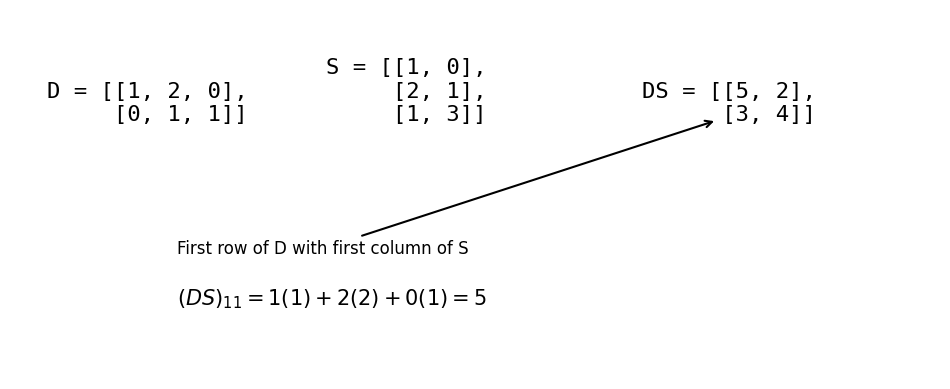

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4.8))
ax.axis('off')

ax.text(0.04, 0.70, 'D = [[1, 2, 0],\n     [0, 1, 1]]',
        fontsize=16, family='monospace')

ax.text(0.34, 0.70, 'S = [[1, 0],\n     [2, 1],\n     [1, 3]]',
        fontsize=16, family='monospace')

ax.text(0.68, 0.70, 'DS = [[5, 2],\n      [3, 4]]',
        fontsize=16, family='monospace')

ax.annotate(
    'First row of D with first column of S',
    xy=(0.76, 0.70),
    xytext=(0.18, 0.34),
    arrowprops=dict(arrowstyle='->', lw=1.5),
    fontsize=12
)

ax.text(0.18, 0.20, r'$(DS)_{11}=1(1)+2(2)+0(1)=5$', fontsize=15)

plt.show()


## Again: Matrix equations and column combinations

Consider

$$
A=\begin{bmatrix}
1&1&1\\
2&1&0\\
0&1&2
\end{bmatrix},
\qquad
\mathbf{x}=\begin{bmatrix}9\\20\\21\end{bmatrix}.
$$

Then

$$
A\mathbf{x}
=9\begin{bmatrix}1\\2\\0\end{bmatrix}
+20\begin{bmatrix}1\\1\\1\end{bmatrix}
+21\begin{bmatrix}1\\0\\2\end{bmatrix}
=\begin{bmatrix}50\\38\\62\end{bmatrix}.
$$

This illustrates a central interpretation:

> $A\mathbf{x}$ is a linear combination of the columns of $A$, using the entries of $\mathbf{x}$ as coefficients.

In [9]:
A_sys = sp.Matrix([[1,1,1],[2,1,0],[0,1,2]])
x_sys = sp.Matrix([9,20,21])
b_sys = A_sys*x_sys
show_matrix(A_sys, 'A')
show_matrix(x_sys, r'\mathbf{x}')
show_matrix(b_sys, r'A\mathbf{x}')
columns = A_sys.columnspace()
combination = sum((x_sys[i]*A_sys[:,i] for i in range(A_sys.cols)), sp.zeros(A_sys.rows,1))
show_matrix(combination, r'9\mathbf{a}_1+20\mathbf{a}_2+21\mathbf{a}_3')

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

⎡50⎤
⎢  ⎥
⎢38⎥
⎢  ⎥
⎣62⎦

## Partitioned matrices

A matrix can be divided into blocks when the partitions are compatible. For example,

$$
A=\left[\begin{array}{cc|c}
1&1&1\\2&1&0\\0&1&2
\end{array}\right]
=\begin{bmatrix}A_1&A_2\end{bmatrix},
$$

where $A_1$ contains the first two columns and $A_2$ contains the third. Block notation is useful when a matrix has a natural structure or when several right-hand sides are solved at once.

> **Closing note**
> Matrix operations are not isolated rules. Addition combines compatible datasets, multiplication composes relationships, and the matrix equation connects matrix algebra to systems of linear equations and column combinations.

## Section 2.1 terminology

| Term | Meaning |
|---|---|
| Matrix | Rectangular array of numbers or expressions |
| Size / order | Number of rows by number of columns |
| Entry $a_{ij}$ | Entry in row $i$, column $j$ |
| Row vector | Matrix with one row |
| Column vector | Matrix with one column |
| Matrix equality | Same size and equal corresponding entries |
| Scalar multiple | Matrix obtained by multiplying every entry by a scalar |
| Matrix product | Row-column multiplication when inner dimensions agree |
| Matrix equation | Equation such as $A\mathbf{x}=\mathbf{b}$ |
| Partitioned matrix | Matrix divided into compatible blocks |
| Linear combination | Weighted sum of vectors or matrix columns |

## Section 2.1 worksheet

1. Determine the size of each matrix and identify the requested entry.

$$
A=\begin{bmatrix}9&20&21\\1&5&7\end{bmatrix},
\qquad B=\begin{bmatrix}4\\8\\12\end{bmatrix}.
$$

Find the sizes of $A$ and $B$, $a_{23}$, and $b_{31}$.

2. Find $p$ and $q$ so that

$$
\begin{bmatrix}p&9\\20&q\end{bmatrix}
=\begin{bmatrix}1&9\\20&21\end{bmatrix}.
$$

3. Given

$$
C=\begin{bmatrix}2&-1\\4&3\end{bmatrix},
\qquad D=\begin{bmatrix}5&2\\-1&6\end{bmatrix},
$$

find $C+D$, $C-D$, and $3C-2D$.

4. Determine whether each product is defined and state its size:

- $(3\times4)(4\times2)$
- $(2\times3)(2\times2)$
- $(1\times5)(5\times1)$

5. Compute

$$
\begin{bmatrix}1&2&1\\0&1&3\end{bmatrix}
\begin{bmatrix}2&1\\1&0\\3&2\end{bmatrix}.
$$

6. Write the system as $A\mathbf{x}=\mathbf{b}$ and express $\mathbf{b}$ as a linear combination of the columns of $A$:

$$
\begin{cases}
x+2y-z=9,\\
2x+y+3z=20.
\end{cases}
$$

> Use the individual reveal buttons below one problem at a time after students have worked on the questions.

## Section 2.1 Instructor Answer Reveals

Reveal one solution at a time during class. The complete solutions are stored in the hidden instructor answer bank.

In [10]:
reveal_answer_key("2.1-1", "Reveal Problem 1")
reveal_answer_key("2.1-2", "Reveal Problem 2")
reveal_answer_key("2.1-3", "Reveal Problem 3")
reveal_answer_key("2.1-4", "Reveal Problem 4")
reveal_answer_key("2.1-5", "Reveal Problem 5")
reveal_answer_key("2.1-6", "Reveal Problem 6")

ToggleButton(value=False, button_style='info', description='Reveal Problem 6', icon='eye', layout=Layout(width…


> **Classroom checkpoint — Check dimensions before multiplying**
> Work independently or in small groups before clicking the reveal button below.

Let $A=\begin{bmatrix}1&2&-1\\0&3&4\end{bmatrix}$ and $B=\begin{bmatrix}2&1\\-1&0\\3&2\end{bmatrix}$. Which of $AB$ and $BA$ are defined, what are their sizes, and what are the products?


In [11]:
reveal_answer_key("checkpoint-2.1", "Reveal checkpoint answer")

ToggleButton(value=False, button_style='info', description='Reveal checkpoint answer', icon='eye', layout=Layo…

# Section 2.2 - Properties of Matrix Operations

## Learning objectives

Students should be able to:

- use algebraic properties of addition and scalar multiplication;
- work with zero and identity matrices;
- use associativity and distributivity of matrix multiplication;
- recognize that matrix multiplication is generally not commutative;
- solve simple matrix equations;
- compute transposes and apply transpose identities.

## Algebra of Matrix Addition and Scalar Multiplication

For matrices $A,B,C$ of the same size and scalars $c,d$, the following properties hold.

1. **Commutative property of matrix addition**

   $$
   A+B=B+A.
   $$

2. **Associative property of matrix addition**

   $$
   A+(B+C)=(A+B)+C.
   $$

3. **Additive identity**

   $$
   A+O=A.
   $$

4. **Additive inverse**

   $$
   A+(-A)=O.
   $$

5. **Distributive property over scalar addition**

   $$
   (c+d)A=cA+dA.
   $$

6. **Distributive property over matrix addition**

   $$
   c(A+B)=cA+cB.
   $$

7. **Associative property of scalar multiplication**

   $$
   (cd)A=c(dA).
   $$

8. **Scalar multiplicative identity**

   $$
   1A=A.
   $$

### Original example: solving a matrix equation

Solve

$$
3X+A=B,
$$

where

$$
A=\begin{bmatrix}1&9\\20&21\end{bmatrix},
\qquad
B=\begin{bmatrix}10&30\\41&42\end{bmatrix}.
$$

Subtract $A$ from both sides:

$$
3X=B-A
=\begin{bmatrix}9&21\\21&21\end{bmatrix}.
$$

Multiply by $\frac13$:

$$
X=\frac13(B-A)
=\begin{bmatrix}3&7\\7&7\end{bmatrix}.
$$

In [12]:
A22 = sp.Matrix([[1,9],[20,21]])
B22 = sp.Matrix([[10,30],[41,42]])
X22 = sp.Rational(1,3)*(B22-A22)
show_matrix(A22,'A')
show_matrix(B22,'B')
show_matrix(B22-A22,'B-A')
show_matrix(X22,'X')
show_matrix(3*X22+A22,'3X+A')

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

⎡10  30⎤
⎢      ⎥
⎣41  42⎦

## Properties of matrix multiplication

When sizes are compatible:

$$
A(BC)=(AB)C,
$$

$$
A(B+C)=AB+AC,
\qquad
(A+B)C=AC+BC,
$$

$$
c(AB)=(cA)B=A(cB).
$$

Matrix multiplication is associative, but it is generally **not commutative**.

### Detailed associativity example

Let

$$
A=\begin{bmatrix}1&2&0\\0&1&1\end{bmatrix},
\quad
B=\begin{bmatrix}1&0\\2&1\\1&3\end{bmatrix},
\quad
C=\begin{bmatrix}2&1\\0&1\end{bmatrix}.
$$

First group as $(AB)C$:

$$
AB=\begin{bmatrix}5&2\\3&4\end{bmatrix},
$$

so

$$
(AB)C
=\begin{bmatrix}5&2\\3&4\end{bmatrix}
\begin{bmatrix}2&1\\0&1\end{bmatrix}
=\begin{bmatrix}10&7\\6&7\end{bmatrix}.
$$

Now group as $A(BC)$:

$$
BC=\begin{bmatrix}2&1\\4&3\\2&4\end{bmatrix},
$$

so

$$
A(BC)
=\begin{bmatrix}1&2&0\\0&1&1\end{bmatrix}
\begin{bmatrix}2&1\\4&3\\2&4\end{bmatrix}
=\begin{bmatrix}10&7\\6&7\end{bmatrix}.
$$

Both groupings give the same result.

In [13]:
A_assoc=sp.Matrix([[1,2,0],[0,1,1]])
B_assoc=sp.Matrix([[1,0],[2,1],[1,3]])
C_assoc=sp.Matrix([[2,1],[0,1]])
show_matrix(A_assoc*B_assoc,'AB')
show_matrix((A_assoc*B_assoc)*C_assoc,'(AB)C')
show_matrix(B_assoc*C_assoc,'BC')
show_matrix(A_assoc*(B_assoc*C_assoc),'A(BC)')
print('Associativity verified:', (A_assoc*B_assoc)*C_assoc == A_assoc*(B_assoc*C_assoc))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Associativity verified: True


### Matrix multiplication is not commutative

Let

$$
P=\begin{bmatrix}1&1\\0&1\end{bmatrix},
\qquad
Q=\begin{bmatrix}1&0\\1&1\end{bmatrix}.
$$

Then

$$
PQ=\begin{bmatrix}2&1\\1&1\end{bmatrix},
\qquad
QP=\begin{bmatrix}1&1\\1&2\end{bmatrix}.
$$

Therefore, $PQ\ne QP$. The order of transformations matters.

In [14]:
P=sp.Matrix([[1,1],[0,1]])
Q=sp.Matrix([[1,0],[1,1]])
show_matrix(P*Q,'PQ')
show_matrix(Q*P,'QP')
print('Do they commute?', P*Q == Q*P)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Do they commute? False


## Identity and Zero Matrices

For an $m\times n$ matrix $A$, the appropriate identity matrices satisfy

$$
AI_n=A,
\qquad
I_mA=A.
$$

For example, let

$$
A=
\begin{bmatrix}
1&2&3\\
4&5&6
\end{bmatrix}.
$$

Since $A$ is $2\times3$, multiplication on the right uses $I_3$ and multiplication on the left uses $I_2$:

$$
AI_3=A,
\qquad
I_2A=A.
$$

The zero matrix is the additive identity:

$$
A+O=A.
$$

A major difference from ordinary scalar algebra is that

$$
AB=O
$$

does **not** imply $A=O$ or $B=O$. For example,

$$
A=
\begin{bmatrix}
1&-1\\
1&-1
\end{bmatrix},
\qquad
B=
\begin{bmatrix}
1&1\\
1&1
\end{bmatrix}
$$

are both nonzero, but

$$
AB=
\begin{bmatrix}
0&0\\
0&0
\end{bmatrix}.
$$

### Classroom Question: Does a Zero Product Force a Zero Factor?

If $AB=O$, must $A=O$ or $B=O$?

Ask students to compare this with ordinary real-number multiplication before revealing the counterexample.

In [15]:
reveal_answer_key("concept-zero-product", "Reveal counterexample")

ToggleButton(value=False, button_style='info', description='Reveal counterexample', icon='eye', layout=Layout(…

## Transpose

The transpose of $A=[a_{ij}]$ is $A^T=[a_{ji}]$: rows become columns.

If

$$
M=
\begin{bmatrix}
9&20&21\\
1&5&7
\end{bmatrix},
$$

then

$$
M^T=
\begin{bmatrix}
9&1\\
20&5\\
21&7
\end{bmatrix}.
$$

Important transpose properties are:

1. **Double-transpose property**

   $$
   (A^T)^T=A.
   $$

2. **Transpose of a sum**

   $$
   (A+B)^T=A^T+B^T.
   $$

3. **Transpose of a scalar multiple**

   $$
   (cA)^T=cA^T.
   $$

4. **Transpose of a product**

   $$
   (AB)^T=B^TA^T.
   $$

The order reverses in the product identity. **This reversal is essential.**

### Classroom Question: Why Does the Transpose Reverse the Order?

Why is the product rule

$$
(AB)^T=B^TA^T
$$

rather than $A^TB^T$?

Have students check the matrix dimensions before revealing the explanation.

In [16]:
reveal_answer_key("concept-transpose-order", "Reveal explanation")

ToggleButton(value=False, button_style='info', description='Reveal explanation', icon='eye', layout=Layout(wid…

In [17]:
M=sp.Matrix([[9,20,21],[1,5,7]])
show_matrix(M,'M')
show_matrix(M.T,'M^T')
show_matrix((A_assoc*B_assoc).T,'(AB)^T')
show_matrix(B_assoc.T*A_assoc.T,'B^TA^T')
print('Transpose product identity verified:', (A_assoc*B_assoc).T == B_assoc.T*A_assoc.T)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Transpose product identity verified: True


> **Closing note**
> Matrix algebra resembles ordinary algebra in many ways, but multiplication has a directional structure. Associativity and distributivity survive; commutativity generally does not. The transpose also reverses multiplication order.

## Section 2.2 terminology

| Term | Meaning |
|---|---|
| Zero matrix $O$ | Matrix whose entries are all zero |
| Additive inverse $-A$ | Matrix satisfying $A+(-A)=O$ |
| Identity matrix $I_n$ | Square matrix with ones on the main diagonal |
| Associative property | Grouping does not change a valid product or sum |
| Distributive property | Multiplication distributes over addition |
| Commutative property | Order can be reversed; generally false for matrix multiplication |
| Transpose $A^T$ | Matrix formed by interchanging rows and columns |
| Symmetric matrix | Square matrix satisfying $A^T=A$ |

## Section 2.2 worksheet

1. Solve $4X-A=B$ for $X$, where

$$
A=\begin{bmatrix}4&8\\12&16\end{bmatrix},
\qquad
B=\begin{bmatrix}8&0\\4&20\end{bmatrix}.
$$

2. Verify $c(A+B)=cA+cB$ for

$$
A=\begin{bmatrix}1&2\\3&4\end{bmatrix},
\quad
B=\begin{bmatrix}5&-1\\2&0\end{bmatrix},
\quad c=3.
$$

3. Compute $AB$ and $BA$ for

$$
A=\begin{bmatrix}1&2\\0&1\end{bmatrix},
\qquad
B=\begin{bmatrix}2&0\\1&1\end{bmatrix}.
$$

4. Verify associativity for the matrices

$$
A=\begin{bmatrix}1&0\\2&1\end{bmatrix},
B=\begin{bmatrix}1&2\\0&1\end{bmatrix},
C=\begin{bmatrix}2&1\\1&0\end{bmatrix}.
$$

5. Find $M^T$ and $(M^T)^T$ for

$$
M=\begin{bmatrix}1&9&20\\21&0&5\end{bmatrix}.
$$

6. Verify $(AB)^T=B^TA^T$ for the matrices in Problem 3.

> Use the individual reveal buttons below one problem at a time after students have worked on the questions.

## Section 2.2 Instructor Answer Reveals

Reveal one solution at a time during class. The complete solutions are stored in the hidden instructor answer bank.

In [18]:
reveal_answer_key("2.2-1", "Reveal Problem 1")
reveal_answer_key("2.2-2", "Reveal Problem 2")
reveal_answer_key("2.2-3", "Reveal Problem 3")
reveal_answer_key("2.2-4", "Reveal Problem 4")
reveal_answer_key("2.2-5", "Reveal Problem 5")
reveal_answer_key("2.2-6", "Reveal Problem 6")

ToggleButton(value=False, button_style='info', description='Reveal Problem 6', icon='eye', layout=Layout(width…


> **Classroom checkpoint — Test matrix properties**
> Work independently or in small groups before clicking the reveal button below.

For $A=\begin{bmatrix}1&2\\0&1\end{bmatrix}$ and $B=\begin{bmatrix}2&0\\1&3\end{bmatrix}$, compare $AB$ with $BA$, and verify $(AB)^T=B^TA^T$.


In [19]:
reveal_answer_key("checkpoint-2.2", "Reveal checkpoint answer")

ToggleButton(value=False, button_style='info', description='Reveal checkpoint answer', icon='eye', layout=Layo…

# Section 2.3 - The Inverse of a Matrix

## Learning objectives

Students should be able to:

- explain invertibility and singularity;
- find a $2\times2$ inverse using the formula;
- find an inverse using Gauss-Jordan elimination;
- recognize when an inverse does not exist;
- use inverse properties correctly;
- solve $A\mathbf{x}=\mathbf{b}$ with $A^{-1}$;
- reuse one inverse for several right-hand sides.

> **Definition: inverse**
> A square matrix $A$ is invertible when there exists a matrix $A^{-1}$ satisfying $AA^{-1}=A^{-1}A=I$. If no inverse exists, $A$ is singular. An inverse, when it exists, is unique.

## The $2\times2$ formula

For

$$
A=\begin{bmatrix}a&b\\c&d\end{bmatrix},
$$

$A$ is invertible exactly when $ad-bc\ne0$, and

$$
A^{-1}=\frac{1}{ad-bc}
\begin{bmatrix}d&-b\\-c&a\end{bmatrix}.
$$

### Original example

Let

$$
A=\begin{bmatrix}3&2\\4&3\end{bmatrix}.
$$

The determinant factor is

$$
ad-bc=3(3)-2(4)=1.
$$

Therefore,

$$
A^{-1}=\begin{bmatrix}3&-2\\-4&3\end{bmatrix}.
$$

Check:

$$
AA^{-1}
=\begin{bmatrix}3&2\\4&3\end{bmatrix}
\begin{bmatrix}3&-2\\-4&3\end{bmatrix}
=\begin{bmatrix}1&0\\0&1\end{bmatrix}.
$$

In [20]:
A23_2=sp.Matrix([[3,2],[4,3]])
show_matrix(A23_2,'A')
print('det(A) =', A23_2.det())
show_matrix(A23_2.inv(),'A^{-1}')
show_matrix(A23_2*A23_2.inv(),'AA^{-1}')

<IPython.core.display.Math object>

det(A) = 1


<IPython.core.display.Math object>

<IPython.core.display.Math object>

⎡1  0⎤
⎢    ⎥
⎣0  1⎦

## Gauss-Jordan method for a $3\times3$ inverse

Let

$$
A=\begin{bmatrix}
1&1&0\\
0&1&1\\
1&0&1
\end{bmatrix}.
$$

Adjoin the identity matrix:

$$
\left[\begin{array}{ccc|ccc}
1&1&0&1&0&0\\
0&1&1&0&1&0\\
1&0&1&0&0&1
\end{array}\right].
$$

### Step 1: eliminate the first entry of Row 3

Use $R_3\leftarrow R_3-R_1$:

$$
\left[\begin{array}{ccc|ccc}
1&1&0&1&0&0\\
0&1&1&0&1&0\\
0&-1&1&-1&0&1
\end{array}\right].
$$

### Step 2: eliminate the second entry of Row 3

Use $R_3\leftarrow R_3+R_2$:

$$
\left[\begin{array}{ccc|ccc}
1&1&0&1&0&0\\
0&1&1&0&1&0\\
0&0&2&-1&1&1
\end{array}\right].
$$

### Step 3: scale Row 3

Use $R_3\leftarrow\frac12R_3$:

$$
\left[\begin{array}{ccc|ccc}
1&1&0&1&0&0\\
0&1&1&0&1&0\\
0&0&1&-\frac12&\frac12&\frac12
\end{array}\right].
$$

### Step 4: eliminate the third entry of Row 2

Use $R_2\leftarrow R_2-R_3$:

$$
\left[\begin{array}{ccc|ccc}
1&1&0&1&0&0\\
0&1&0&\frac12&\frac12&-\frac12\\
0&0&1&-\frac12&\frac12&\frac12
\end{array}\right].
$$

### Step 5: eliminate the second entry of Row 1

Use $R_1\leftarrow R_1-R_2$:

$$
\left[\begin{array}{ccc|ccc}
1&0&0&\frac12&-\frac12&\frac12\\
0&1&0&\frac12&\frac12&-\frac12\\
0&0&1&-\frac12&\frac12&\frac12
\end{array}\right].
$$

Thus

$$
A^{-1}=\frac12
\begin{bmatrix}
1&-1&1\\
1&1&-1\\
-1&1&1
\end{bmatrix}.
$$

In [21]:
A23=sp.Matrix([[1,1,0],[0,1,1],[1,0,1]])
M0=A23.row_join(sp.eye(3))
show_augmented(M0,3,r'[A\mid I]')
M1=M0.copy(); M1[2,:]=M1[2,:]-M1[0,:]
show_augmented(M1,3,r'R_3\leftarrow R_3-R_1')
M2=M1.copy(); M2[2,:]=M2[2,:]+M2[1,:]
show_augmented(M2,3,r'R_3\leftarrow R_3+R_2')
M3=M2.copy(); M3[2,:]=sp.Rational(1,2)*M3[2,:]
show_augmented(M3,3,r'R_3\leftarrow \frac12R_3')
M4=M3.copy(); M4[1,:]=M4[1,:]-M4[2,:]
show_augmented(M4,3,r'R_2\leftarrow R_2-R_3')
M5=M4.copy(); M5[0,:]=M5[0,:]-M5[1,:]
show_augmented(M5,3,r'R_1\leftarrow R_1-R_2')
show_matrix(A23.inv(),'A^{-1}')

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

⎡1/2   -1/2  1/2 ⎤
⎢                ⎥
⎢1/2   1/2   -1/2⎥
⎢                ⎥
⎣-1/2  1/2   1/2 ⎦

## Singular matrices

For

$$
S=\begin{bmatrix}1&2\\2&4\end{bmatrix},
$$

$ad-bc=4-4=0$. The second row is twice the first, so the matrix cannot be reduced to $I_2$. Therefore, $S$ is singular.

In [22]:
Ssing=sp.Matrix([[1,2],[2,4]])
print('det(S) =', Ssing.det())
print('rank(S) =', Ssing.rank())
print('RREF:', Ssing.rref()[0])

det(S) = 0
rank(S) = 1
RREF: Matrix([[1, 2], [0, 0]])


## Properties of Inverses

For invertible matrices $A$ and $B$ and a nonzero scalar $c$:

1. **Inverse of an inverse**

   $$
   (A^{-1})^{-1}=A.
   $$

2. **Inverse of a scalar multiple**

   $$
   (cA)^{-1}=\frac{1}{c}A^{-1}.
   $$

3. **Inverse of a transpose**

   $$
   (A^T)^{-1}=(A^{-1})^T.
   $$

4. **Inverse of a product**

   $$
   (AB)^{-1}=B^{-1}A^{-1}.
   $$

The inverse of a product reverses the order. In general,

$$
(AB)^{-1}\ne A^{-1}B^{-1}.
$$

### Classroom Question: Why Does the Inverse Reverse the Order?

Why is

$$
(AB)^{-1}=B^{-1}A^{-1}?
$$

Ask students which operation must be undone first.

In [23]:
reveal_answer_key("concept-inverse-order", "Reveal explanation")

ToggleButton(value=False, button_style='info', description='Reveal explanation', icon='eye', layout=Layout(wid…

## Solving a system with an inverse

Use the same matrix

$$
A=\begin{bmatrix}1&1&0\\0&1&1\\1&0&1\end{bmatrix}
$$

and solve

$$
A\mathbf{x}=\begin{bmatrix}29\\41\\30\end{bmatrix}.
$$

Multiply by $A^{-1}$:

$$
\mathbf{x}=A^{-1}\mathbf{b}
=\frac12
\begin{bmatrix}1&-1&1\\1&1&-1\\-1&1&1\end{bmatrix}
\begin{bmatrix}29\\41\\30\end{bmatrix}.
$$

Compute each entry:

$$
\begin{aligned}
x_1&=\frac12(29-41+30)=9,\\
x_2&=\frac12(29+41-30)=20,\\
x_3&=\frac12(-29+41+30)=21.
\end{aligned}
$$

Therefore,

$$
\mathbf{x}=\begin{bmatrix}9\\20\\21\end{bmatrix}.
$$

In [24]:
b23=sp.Matrix([29,41,30])
x23=A23.inv()*b23
show_matrix(b23,r'\mathbf{b}')
show_matrix(x23,r'A^{-1}\mathbf{b}')
show_matrix(A23*x23,r'A\mathbf{x}')

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

⎡29⎤
⎢  ⎥
⎢41⎥
⎢  ⎥
⎣30⎦

> **Multiple right-hand sides**
> If the same coefficient matrix is used with many right-hand-side vectors, computing the inverse once allows all solutions to be organized in one matrix equation.

> **Closing note**
> An inverse reverses the action of an invertible matrix. The Gauss-Jordan method explains both how to find the inverse and how singularity appears when the left block cannot become the identity.

## Section 2.3 terminology

| Term | Meaning |
|---|---|
| Invertible / nonsingular | Matrix with a multiplicative inverse |
| Singular | Matrix without an inverse |
| Inverse $A^{-1}$ | Matrix satisfying $AA^{-1}=A^{-1}A=I$ |
| Adjoining $I$ | Forming $[A\mid I]$ for Gauss-Jordan inversion |
| Determinant factor $ad-bc$ | Test used in the $2\times2$ inverse formula |
| Inverse of a product | $(AB)^{-1}=B^{-1}A^{-1}$ |
| Cancellation | Valid when the cancelled matrix is invertible |

## Section 2.3 worksheet

1. Find the inverse of

$$
A=\begin{bmatrix}2&1\\5&3\end{bmatrix}
$$

using the $2\times2$ formula and verify the result.

2. Determine whether

$$
B=\begin{bmatrix}3&6\\1&2\end{bmatrix}
$$

is invertible.

3. Find the inverse of

$$
C=\begin{bmatrix}1&1&0\\0&1&1\\1&1&1\end{bmatrix}
$$

by Gauss-Jordan elimination. Show every row operation.

4. Solve

$$
\begin{bmatrix}3&2\\4&3\end{bmatrix}
\begin{bmatrix}x\\y\end{bmatrix}
=\begin{bmatrix}9\\13\end{bmatrix}
$$

using an inverse.

5. Let

$$
P=\begin{bmatrix}1&1\\0&1\end{bmatrix},
\qquad
Q=\begin{bmatrix}1&0\\1&1\end{bmatrix}.
$$

Find $(PQ)^{-1}$ in two ways and verify that $(PQ)^{-1}=Q^{-1}P^{-1}$.

> Use the individual reveal buttons below one problem at a time after students have worked on the questions.

## Section 2.3 Instructor Answer Reveals

Reveal one solution at a time during class. The complete solutions are stored in the hidden instructor answer bank.

In [25]:
reveal_answer_key("2.3-1", "Reveal Problem 1")
reveal_answer_key("2.3-2", "Reveal Problem 2")
reveal_answer_key("2.3-3", "Reveal Problem 3")
reveal_answer_key("2.3-4", "Reveal Problem 4")
reveal_answer_key("2.3-5", "Reveal Problem 5")

ToggleButton(value=False, button_style='info', description='Reveal Problem 5', icon='eye', layout=Layout(width…


> **Classroom checkpoint — Use an inverse to solve**
> Work independently or in small groups before clicking the reveal button below.

For $A=\begin{bmatrix}2&1\\5&3\end{bmatrix}$ and $b=\begin{bmatrix}7\\19\end{bmatrix}$, determine whether $A$ is invertible and solve $Ax=b$ using $A^{-1}$.


In [26]:
reveal_answer_key("checkpoint-2.3", "Reveal checkpoint answer")

ToggleButton(value=False, button_style='info', description='Reveal checkpoint answer', icon='eye', layout=Layo…

# Section 2.4 - Elementary Matrices and LU-Factorization

## Learning objectives

Students should be able to:

- construct elementary matrices;
- represent row operations by left multiplication;
- explain row equivalence using products of elementary matrices;
- factor an invertible matrix into elementary matrices;
- find an LU-factorization;
- solve $A\mathbf{x}=\mathbf{b}$ using forward and back substitution.

> **Definition: elementary matrix**
> An elementary matrix is obtained by performing one elementary row operation on an identity matrix. Left multiplication by that elementary matrix performs the same row operation on any compatible matrix.

## The three types of elementary matrices

Starting with $I_3$:

1. Swap $R_1$ and $R_2$:

$$
E_{\text{swap}}=\begin{bmatrix}0&1&0\\1&0&0\\0&0&1\end{bmatrix}.
$$

2. Scale $R_2$ by $5$:

$$
E_{\text{scale}}=\begin{bmatrix}1&0&0\\0&5&0\\0&0&1\end{bmatrix}.
$$

3. Replace $R_3$ by $R_3-2R_1$:

$$
E_{\text{replace}}=\begin{bmatrix}1&0&0\\0&1&0\\-2&0&1\end{bmatrix}.
$$

In [27]:
I3=sp.eye(3)
E_swap=sp.Matrix([[0,1,0],[1,0,0],[0,0,1]])
E_scale=sp.diag(1,5,1)
E_replace=sp.Matrix([[1,0,0],[0,1,0],[-2,0,1]])
show_matrix(E_swap,'E_{swap}')
show_matrix(E_scale,'E_{scale}')
show_matrix(E_replace,'E_{replace}')

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

⎡1   0  0⎤
⎢        ⎥
⎢0   1  0⎥
⎢        ⎥
⎣-2  0  1⎦

### Left multiplication performs the row operation

Let

$$
A=\begin{bmatrix}1&2\\3&4\\5&6\end{bmatrix}.
$$

Then

$$
E_{\text{replace}}A
=\begin{bmatrix}1&2\\3&4\\3&2\end{bmatrix},
$$

which is exactly the result of $R_3\leftarrow R_3-2R_1$.

In [28]:
A_elem=sp.Matrix([[1,2],[3,4],[5,6]])
show_matrix(A_elem,'A')
show_matrix(E_replace*A_elem,'E_{replace}A')

<IPython.core.display.Math object>

<IPython.core.display.Math object>

⎡1  2⎤
⎢    ⎥
⎢3  4⎥
⎢    ⎥
⎣3  2⎦

## Factoring a matrix into elementary matrices

Let

$$
A=\begin{bmatrix}1&2\\3&7\end{bmatrix}.
$$

Reduce $A$ to $I_2$:

$$
R_2\leftarrow R_2-3R_1
\quad\Longrightarrow\quad
\begin{bmatrix}1&2\\0&1\end{bmatrix}.
$$

Then

$$
R_1\leftarrow R_1-2R_2
\quad\Longrightarrow\quad
I_2.
$$

The corresponding elementary matrices are

$$
E_1=\begin{bmatrix}1&0\\-3&1\end{bmatrix},
\qquad
E_2=\begin{bmatrix}1&-2\\0&1\end{bmatrix}.
$$

Since $E_2E_1A=I$, we have

$$
A=E_1^{-1}E_2^{-1}
=\begin{bmatrix}1&0\\3&1\end{bmatrix}
\begin{bmatrix}1&2\\0&1\end{bmatrix}.
$$

In [29]:
A_fact=sp.Matrix([[1,2],[3,7]])
E1=sp.Matrix([[1,0],[-3,1]])
E2=sp.Matrix([[1,-2],[0,1]])
show_matrix(E2*E1*A_fact,'E_2E_1A')
show_matrix(E1.inv()*E2.inv(),'E_1^{-1}E_2^{-1}')

<IPython.core.display.Math object>

<IPython.core.display.Math object>

⎡1  2⎤
⎢    ⎥
⎣3  7⎦

## LU-Factorization

An LU-factorization writes

$$
A=LU,
$$

where $L$ is lower triangular and $U$ is upper triangular. In elimination without row exchanges, $L$ records the elimination multipliers.

Consider

$$
A=
\begin{bmatrix}
2&1&-1\\
4&5&0\\
-2&8&11
\end{bmatrix}.
$$

For an entry below a pivot, use the multiplier

$$
m_{ij}=\frac{\text{entry to eliminate}}{\text{pivot}},
$$

and perform

$$
R_i\leftarrow R_i-m_{ij}R_j.
$$

### Step 1: eliminate the $(2,1)$ entry

The pivot is $2$, so

$$
m_{21}=\frac{4}{2}=2.
$$

Use

$$
R_2\leftarrow R_2-2R_1.
$$

This gives

$$
\begin{bmatrix}
2&1&-1\\
0&3&2\\
-2&8&11
\end{bmatrix}.
$$

### Step 2: eliminate the $(3,1)$ entry

Now

$$
m_{31}=\frac{-2}{2}=-1.
$$

Therefore

$$
R_3\leftarrow R_3-(-1)R_1=R_3+R_1,
$$

giving

$$
\begin{bmatrix}
2&1&-1\\
0&3&2\\
0&9&10
\end{bmatrix}.
$$

Notice that the row operation contains a plus sign, but the multiplier stored in $L$ is still

$$
m_{31}=-1.
$$

### Step 3: eliminate the $(3,2)$ entry

The new pivot is $3$, so

$$
m_{32}=\frac{9}{3}=3.
$$

Use

$$
R_3\leftarrow R_3-3R_2,
$$

which gives

$$
U=
\begin{bmatrix}
2&1&-1\\
0&3&2\\
0&0&4
\end{bmatrix}.
$$

Place the multipliers in $L$ below the diagonal:

$$
L=
\begin{bmatrix}
1&0&0\\
2&1&0\\
-1&3&1
\end{bmatrix}.
$$

Thus

$$
\boxed{A=LU}.
$$

The entries below the diagonal of $L$ are the **multipliers themselves**, not their negatives.

### Classroom Check: The Sign of an LU Multiplier

In the LU example,

$$
R_3\leftarrow R_3+R_1.
$$

Why is the multiplier stored in $L$ equal to

$$
m_{31}=-1
$$

rather than $+1$?

In [30]:
reveal_answer_key("concept-lu-sign", "Reveal multiplier explanation")

ToggleButton(value=False, button_style='info', description='Reveal multiplier explanation', icon='eye', layout…

In [31]:
A_lu=sp.Matrix([[2,1,-1],[4,5,0],[-2,8,11]])
L=sp.Matrix([[1,0,0],[2,1,0],[-1,3,1]])
U=sp.Matrix([[2,1,-1],[0,3,2],[0,0,4]])
show_matrix(A_lu,'A')
show_matrix(L,'L')
show_matrix(U,'U')
show_matrix(L*U,'LU')
print('A = LU?', A_lu == L*U)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

A = LU? True


## Solving a system with LU

Solve

$$
A\mathbf{x}=\mathbf{b},
\qquad
\mathbf{b}=\begin{bmatrix}-9\\49\\290\end{bmatrix}.
$$

Because $A=LU$, first solve

$$
L\mathbf{y}=\mathbf{b}.
$$

This gives

$$
\begin{cases}
y_1=-9,\\
2y_1+y_2=49,\\
-y_1+3y_2+y_3=290.
\end{cases}
$$

Forward substitution:

$$
y_1=-9,
$$

$$
y_2=49-2(-9)=67,
$$

$$
y_3=290+y_1-3y_2=290-9-201=80.
$$

Thus

$$
\mathbf{y}=\begin{bmatrix}-9\\67\\80\end{bmatrix}.
$$

Now solve

$$
U\mathbf{x}=\mathbf{y}.
$$

The equations are

$$
\begin{cases}
2x_1+x_2-x_3=-9,\\
3x_2+2x_3=67,\\
4x_3=80.
\end{cases}
$$

Back substitution:

$$
x_3=20,
$$

$$
3x_2+40=67 \quad\Longrightarrow\quad x_2=9,
$$

$$
2x_1+9-20=-9 \quad\Longrightarrow\quad x_1=1.
$$

Therefore,

$$
\mathbf{x}=\begin{bmatrix}1\\9\\20\end{bmatrix}.
$$

In [32]:
b_lu=sp.Matrix([-9,49,290])
y=L.inv()*b_lu
x=U.inv()*y
show_matrix(y,r'\mathbf{y}')
show_matrix(x,r'\mathbf{x}')
show_matrix(A_lu*x,r'A\mathbf{x}')

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

⎡-9 ⎤
⎢   ⎥
⎢49 ⎥
⎢   ⎥
⎣290⎦

> **Why LU is useful**
> When many systems share the same coefficient matrix, factor $A=LU$ once. Each new right-hand side then requires only one forward substitution and one back substitution.

> **Closing note**
> Elementary matrices convert row operations into matrix multiplication. LU-factorization records the elimination process in two triangular matrices, making repeated system solving efficient and conceptually transparent.

## Section 2.4 terminology

| Term | Meaning |
|---|---|
| Elementary matrix | Identity matrix after one elementary row operation |
| Row equivalent | Related by a finite sequence of elementary row operations |
| Lower triangular matrix | Entries above the main diagonal are zero |
| Upper triangular matrix | Entries below the main diagonal are zero |
| LU-factorization | Factorization $A=LU$ |
| Elimination multiplier | Number used to eliminate an entry below a pivot |
| Forward substitution | Solve a lower triangular system from top to bottom |
| Back substitution | Solve an upper triangular system from bottom to top |

## Section 2.4 worksheet

1. Construct the $3\times3$ elementary matrix that performs each operation:

- $R_1\leftrightarrow R_3$
- $R_2\leftarrow -2R_2$
- $R_3\leftarrow R_3+4R_1$

2. Let

$$
A=\begin{bmatrix}1&2\\3&5\\4&7\end{bmatrix}.
$$

Use an elementary matrix to perform $R_3\leftarrow R_3-4R_1$ and verify by multiplication.

3. Factor

$$
B=\begin{bmatrix}1&3\\2&7\end{bmatrix}
$$

as a product of elementary matrices.

4. Find an LU-factorization of

$$
C=\begin{bmatrix}2&1&0\\4&3&1\\-2&2&4\end{bmatrix}.
$$

5. Use your factorization from Problem 4 to solve

$$
C\mathbf{x}=\begin{bmatrix}4\\11\\14\end{bmatrix}.
$$

> Use the individual reveal buttons below one problem at a time after students have worked on the questions.

## Section 2.4 Instructor Answer Reveals

Reveal one solution at a time during class. The complete solutions are stored in the hidden instructor answer bank.

In [33]:
reveal_answer_key("2.4-1", "Reveal Problem 1")
reveal_answer_key("2.4-2", "Reveal Problem 2")
reveal_answer_key("2.4-3", "Reveal Problem 3")
reveal_answer_key("2.4-4", "Reveal Problem 4")
reveal_answer_key("2.4-5", "Reveal Problem 5")

ToggleButton(value=False, button_style='info', description='Reveal Problem 5', icon='eye', layout=Layout(width…


> **Classroom checkpoint — Solve with LU factorization**
> Work independently or in small groups before clicking the reveal button below.

Factor $A=\begin{bmatrix}2&1&1\\4&-6&0\\-2&7&2\end{bmatrix}$ as $LU$, then solve $Ax=b$ for $b=(5,-2,9)^T$ by forward and back substitution.


In [34]:
reveal_answer_key("checkpoint-2.4", "Reveal checkpoint answer")

ToggleButton(value=False, button_style='info', description='Reveal checkpoint answer', icon='eye', layout=Layo…

# Section 2.5 - Markov Chains

## Learning objectives

Students should be able to:

- recognize a column-stochastic matrix;
- compute state vectors using $\mathbf{x}_{k+1}=P\mathbf{x}_k$;
- compute an $n$th state using $P^n\mathbf{x}_0$;
- find a steady state from $P\mathbf{q}=\mathbf{q}$;
- identify regular and absorbing chains;
- interpret long-run behavior in applications.

> **Convention Used in This Course**
>
> State vectors are written as column vectors. The entry $p_{ij}$ represents the probability of moving **from state $j$ to state $i$**.
>
> Therefore:
>
> - each column of the transition matrix $P$ sums to $1$;
> - column $j$ describes what happens next to members currently in state $j$;
> - the next state is
>
>   $$
>   \mathbf{x}_{k+1}=P\mathbf{x}_k;
>   $$
>
> - after $n$ transitions,
>
>   $$
>   \mathbf{x}_n=P^n\mathbf{x}_0.
>   $$

## Stochastic Matrices

A **column-stochastic matrix** has nonnegative entries and each column sums to $1$.



### Interpreting the Transition Matrix (Original two-state R&B/pop model)

Suppose listeners are classified each week into one of two states:

- **State 1:** primarily listens to R\&B
- **State 2:** primarily listens to Pop

We use the transition matrix

$$
P=
\begin{bmatrix}
0.80&0.30\\
0.20&0.70
\end{bmatrix}.
$$

In this course, we use the **column-stochastic convention**:

> **Columns represent the current state, and rows represent the next state.**

So the matrix can be labeled as

$$
\begin{array}{c|cc}
&\text{Current R\&B}&\text{Current Pop}\\
\hline
\text{Next R\&B}&0.80&0.30\\
\text{Next Pop}&0.20&0.70
\end{array}.
$$

This labeling is extremely important.

The entry

$$
p_{ij}
$$

represents the probability of moving

$$
\boxed{\text{from current state }j\text{ to next state }i}.
$$

So the **column tells us where the listener is now**, while the **row tells us where the listener will be next week**.

---

### Interpreting the First Column

The first column is

$$
\begin{bmatrix}
0.80\\
0.20
\end{bmatrix}.
$$

This column describes what happens to a listener who is **currently classified as an R\&B listener**.

Therefore,

$$
p_{11}=0.80
$$

means:

> A listener who is currently in the R\&B group has an $80\%$ probability of remaining in the R\&B group next week.

Similarly,

$$
p_{21}=0.20
$$

means:

> A listener who is currently in the R\&B group has a $20\%$ probability of switching to the Pop group next week.

Thus,

$$
\begin{bmatrix}
0.80\\
0.20
\end{bmatrix}
$$

can be interpreted as

$$
\boxed{
\text{Current R\&B}
\longrightarrow
\begin{cases}
80\% \text{ next-week R\&B},\\
20\% \text{ next-week Pop}.
\end{cases}
}
$$

Notice that

$$
0.80+0.20=1.
$$

This makes sense because a current R\&B listener must be classified as either R\&B or Pop in the next weekly period.

---

### Interpreting the Second Column

The second column is

$$
\begin{bmatrix}
0.30\\
0.70
\end{bmatrix}.
$$

This column describes what happens to a listener who is **currently classified as a Pop listener**.

The entry

$$
p_{12}=0.30
$$

means:

> A listener who is currently in the Pop group has a $30\%$ probability of switching to the R\&B group next week.

The entry

$$
p_{22}=0.70
$$

means:

> A listener who is currently in the Pop group has a $70\%$ probability of remaining in the Pop group next week.

Thus,

$$
\begin{bmatrix}
0.30\\
0.70
\end{bmatrix}
$$

can be interpreted as

$$
\boxed{
\text{Current Pop}
\longrightarrow
\begin{cases}
30\% \text{ next-week R\&B},\\
70\% \text{ next-week Pop}.
\end{cases}
}
$$

Again,

$$
0.30+0.70=1.
$$

---

### Interpreting All Four Entries

We can summarize the entire matrix as follows:

$$
P=
\begin{array}{c|cc}
&\text{Current R\&B}&\text{Current Pop}\\
\hline
\text{Next R\&B}&0.80&0.30\\
\text{Next Pop}&0.20&0.70
\end{array}.
$$

Therefore,

$$
\begin{aligned}
p_{11}=0.80
&:\quad
\text{R\&B}\rightarrow\text{R\&B},\\[4pt]
p_{21}=0.20
&:\quad
\text{R\&B}\rightarrow\text{Pop},\\[4pt]
p_{12}=0.30
&:\quad
\text{Pop}\rightarrow\text{R\&B},\\[4pt]
p_{22}=0.70
&:\quad
\text{Pop}\rightarrow\text{Pop}.
\end{aligned}
$$

A useful way to read an entry is

$$
\boxed{
p_{ij}
=
P(\text{next state}=i\mid\text{current state}=j)
}.
$$

For example,

$$
p_{12}=0.30
$$

should be read as:

> The probability of being in **State 1 (R\&B) next week**, given that the listener is in **State 2 (Pop) this week**, is $0.30$.

---

### Why Do the Columns Sum to 1?

Because each column represents all possible next-week outcomes from one current state.

For a current R\&B listener,

$$
0.80+0.20=1.
$$

For a current Pop listener,

$$
0.30+0.70=1.
$$

Therefore,

$$
\boxed{\text{each column of }P\text{ sums to }1}.
$$

A matrix with nonnegative entries whose columns sum to $1$ is called a **column-stochastic matrix**.

---

### Connecting the Matrix to the State Vector

Let

$$
\mathbf{x}_k=
\begin{bmatrix}
R_k\\
P_k
\end{bmatrix},
$$

where

- $R_k$ is the proportion of listeners classified as R\&B during week $k$;
- $P_k$ is the proportion of listeners classified as Pop during week $k$.

Since every listener belongs to one of the two groups,

$$
R_k+P_k=1.
$$

The next week's distribution is

$$
\boxed{
\mathbf{x}_{k+1}=P\mathbf{x}_k
}.
$$

That is,

$$
\begin{bmatrix}
R_{k+1}\\
P_{k+1}
\end{bmatrix}
=
\begin{bmatrix}
0.80&0.30\\
0.20&0.70
\end{bmatrix}
\begin{bmatrix}
R_k\\
P_k
\end{bmatrix}.
$$

Multiplying gives

$$
R_{k+1}
=
0.80R_k+0.30P_k,
$$

and

$$
P_{k+1}
=
0.20R_k+0.70P_k.
$$

These equations also have a direct interpretation.

For the next week's R\&B proportion,

$$
R_{k+1}
=
\underbrace{0.80R_k}_{\substack{\text{current R\&B listeners}\\\text{who remain R\&B}}}
+
\underbrace{0.30P_k}_{\substack{\text{current Pop listeners}\\\text{who switch to R\&B}}}.
$$

For the next week's Pop proportion,

$$
P_{k+1}
=
\underbrace{0.20R_k}_{\substack{\text{current R$\&B$ listeners}\\\text{who switch to Pop}}}
+
\underbrace{0.70P_k}_{\substack{\text{current Pop listeners}\\\text{who remain Pop}}}.
$$

So matrix multiplication is combining contributions from the two current groups to determine the next week's distribution.

---

> **Key Reading Rule**
>
> For the transition matrix used in this course:
>
> $$
> \boxed{
> \text{Column}=\text{current state},
> \qquad
> \text{Row}=\text{next state}.
> }
> $$
>
> Therefore,
>
> $$
> \boxed{
> p_{ij}
> =
> P(\text{move from state }j\text{ to state }i)
> }.
> $$
>
> Always identify the meaning of the rows and columns before interpreting an entry.


Because we use the column-stochastic convention:

- the first column

  $$
  \begin{bmatrix}0.80\\0.20\end{bmatrix}
  $$

  means that a current R&B listener has probability $0.80$ of remaining in R&B and probability $0.20$ of moving to pop next week;

- the second column

  $$
  \begin{bmatrix}0.30\\0.70\end{bmatrix}
  $$

  means that a current pop listener has probability $0.30$ of moving to R&B and probability $0.70$ of remaining in pop.

Start from

$$
\mathbf{x}_0=
\begin{bmatrix}
0.21\\
0.79
\end{bmatrix}.
$$

The subscript $0$ means **initial state**. The first component is the initial R&B proportion and the second is the initial pop proportion.

Then

$$
\mathbf{x}_1=P\mathbf{x}_0
=
\begin{bmatrix}
0.80(0.21)+0.30(0.79)\\
0.20(0.21)+0.70(0.79)
\end{bmatrix}
=
\begin{bmatrix}
0.405\\
0.595
\end{bmatrix}.
$$

Thus, after one transition, the modeled proportions are $40.5\%$ R&B and $59.5\%$ pop. The entries still add to $1$, as a probability state vector should.

### Classroom Check: Read a Transition-Matrix Column

For

$$
P=
\begin{bmatrix}
0.80&0.30\\
0.20&0.70
\end{bmatrix},
$$

what does the **second column** mean under our course convention?

In [53]:
reveal_answer_key("concept-markov-column", "Reveal interpretation")

ToggleButton(value=False, button_style='info', description='Reveal interpretation', icon='eye', layout=Layout(…

In [36]:
P_music=sp.Matrix([[sp.Rational(4,5),sp.Rational(3,10)],
                   [sp.Rational(1,5),sp.Rational(7,10)]])
x0_music=sp.Matrix([sp.Rational(21,100),sp.Rational(79,100)])
show_matrix(P_music,'P')
show_matrix(x0_music,r'\mathbf{x}_0')
for n in [1,2,3,5,10]:
    show_matrix(sp.N(P_music**n*x0_music,6),rf'\mathbf{{x}}_{n}')

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

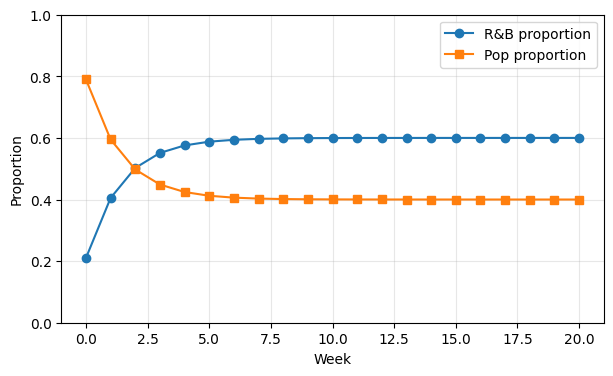

In [37]:
# Convergence plot for the two-state chain.
P_np=np.array(P_music.tolist(),dtype=float)
x=np.array(x0_music,dtype=float).reshape(-1)
history=[x.copy()]
for _ in range(20):
    x=P_np@x
    history.append(x.copy())
history=np.array(history)
plt.figure(figsize=(7,4))
plt.plot(history[:,0],marker='o',label='R&B proportion')
plt.plot(history[:,1],marker='s',label='Pop proportion')
plt.xlabel('Week')
plt.ylabel('Proportion')
plt.ylim(0,1)
plt.grid(alpha=.3)
plt.legend()
plt.show()

## Steady State

A steady state $\mathbf{q}$ is a probability vector that does not change after another transition:

$$
P\mathbf{q}=\mathbf{q},
\qquad
q_1+q_2=1.
$$

For the music model, let

$$
\mathbf{q}=
\begin{bmatrix}
q_1\\q_2
\end{bmatrix}.
$$

Then

$$
\begin{bmatrix}
0.80&0.30\\
0.20&0.70
\end{bmatrix}
\begin{bmatrix}
q_1\\q_2
\end{bmatrix}
=
\begin{bmatrix}
q_1\\q_2
\end{bmatrix}.
$$

The first component gives

$$
0.8q_1+0.3q_2=q_1,
$$

so

$$
0.3q_2=0.2q_1
\quad\Longrightarrow\quad
2q_1=3q_2.
$$

Together with

$$
q_1+q_2=1,
$$

we obtain

$$
q_1=0.6,
\qquad
q_2=0.4.
$$

Therefore,

$$
\boxed{
\mathbf{q}=
\begin{bmatrix}
0.6\\0.4
\end{bmatrix}
}.
$$

A steady state does **not** mean that individual listeners stop switching. It means that the overall proportions remain unchanged from one step to the next.

In [54]:
q1,q2=sp.symbols('q1 q2')
sol=sp.solve([
    sp.Eq(sp.Rational(4,5)*q1+sp.Rational(3,10)*q2,q1),
    sp.Eq(q1+q2,1)
],[q1,q2])
print(sol)
q=sp.Matrix([sol[q1],sol[q2]])
show_matrix(P_music*q,r'P\mathbf{q}')
show_matrix(q,r'\mathbf{q}')

{q1: 3/5, q2: 2/5}


<IPython.core.display.Math object>

<IPython.core.display.Math object>

⎡3/5⎤
⎢   ⎥
⎣2/5⎦

## Three-state travel-mode chain

Let the states be driving, public transit, and walking. Consider

$$
P=\begin{bmatrix}
0.7&0.2&0.1\\
0.2&0.6&0.3\\
0.1&0.2&0.6
\end{bmatrix},
\qquad
\mathbf{x}_0=\begin{bmatrix}0.5\\0.3\\0.2\end{bmatrix}.
$$

The steady state is

$$
\mathbf{q}=\begin{bmatrix}10/29\\11/29\\8/29\end{bmatrix}
\approx
\begin{bmatrix}0.3448\\0.3793\\0.2759\end{bmatrix}.
$$

In [39]:
P_travel=sp.Matrix([[sp.Rational(7,10),sp.Rational(1,5),sp.Rational(1,10)],
                    [sp.Rational(1,5),sp.Rational(3,5),sp.Rational(3,10)],
                    [sp.Rational(1,10),sp.Rational(1,5),sp.Rational(3,5)]])
x0_travel=sp.Matrix([sp.Rational(1,2),sp.Rational(3,10),sp.Rational(1,5)])
for n in [1,2,5,10,25]:
    show_matrix(sp.N(P_travel**n*x0_travel,6),rf'\mathbf{{x}}_{n}')
v=(P_travel-sp.eye(3)).nullspace()[0]
v=sp.simplify(v/sum(v))
show_matrix(v,r'\mathbf{q}')

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

⎡ 10 ⎤
⎢ ── ⎥
⎢ 29 ⎥
⎢    ⎥
⎢ 11 ⎥
⎢ ── ⎥
⎢ 29 ⎥
⎢    ⎥
⎣8/29⎦

## Absorbing Markov Chain: Hiking Outcomes

Consider a fictional hiking process with three possible states:

1. **State 1: Still on the trail**
2. **State 2: Reached the summit**
3. **State 3: Returned to the trailhead**

We use the transition matrix

$$
P=
\begin{bmatrix}
0.5&0&0\\
0.3&1&0\\
0.2&0&1
\end{bmatrix}.
$$

Recall the convention used in this course:

> **Columns represent the current state, and rows represent the next state.**

Therefore, we can label the transition matrix as

$$
P=
\begin{array}{c|ccc}
&\text{Current Trail}&\text{Current Summit}&\text{Current Trailhead}\\
\hline
\text{Next Trail}&0.5&0&0\\
\text{Next Summit}&0.3&1&0\\
\text{Next Trailhead}&0.2&0&1
\end{array}.
$$

Thus,

$$
p_{ij}
$$

represents the probability of moving

$$
\boxed{
\text{from current state }j
\text{ to next state }i
}.
$$

---

### Interpreting the First Column

The first column is

$$
\begin{bmatrix}
0.5\\
0.3\\
0.2
\end{bmatrix}.
$$

This column describes what happens to a hiker who is **currently still on the trail**.

Therefore,

$$
p_{11}=0.5
$$

means:

> A hiker who is currently on the trail has a $50\%$ probability of still being on the trail after the next transition.

The entry

$$
p_{21}=0.3
$$

means:

> A hiker who is currently on the trail has a $30\%$ probability of reaching the summit during the next transition.

The entry

$$
p_{31}=0.2
$$

means:

> A hiker who is currently on the trail has a $20\%$ probability of returning to the trailhead during the next transition.

These probabilities add to

$$
0.5+0.3+0.2=1.
$$

So every hiker who is currently on the trail must, after one transition,

- remain on the trail,
- reach the summit, or
- return to the trailhead.

---

### Why Are the Summit and Trailhead States Absorbing?

Now consider the second column:

$$
\begin{bmatrix}
0\\
1\\
0
\end{bmatrix}.
$$

This column corresponds to a hiker who has **already reached the summit**.

It says

$$
P(\text{next state = summit}\mid\text{current state = summit})=1.
$$

Therefore, once the process enters the summit state, it remains there.

Similarly, the third column is

$$
\begin{bmatrix}
0\\
0\\
1
\end{bmatrix}.
$$

This means that once a hiker has returned to the trailhead, the process remains in the trailhead state.

Therefore,

$$
\boxed{
\text{State 2 and State 3 are absorbing states.}
}
$$

The trail state is not absorbing because a hiker can leave it.

---

### Initial State

Suppose every hiker starts on the trail.

Then the initial state vector is

$$
\mathbf{x}_0=
\begin{bmatrix}
1\\
0\\
0
\end{bmatrix}.
$$

We can label its entries as

$$
\mathbf{x}_0=
\begin{array}{c}
\text{Trail}\\
\text{Summit}\\
\text{Trailhead}
\end{array}
\left[
\begin{array}{c}
1\\
0\\
0
\end{array}
\right].
$$

Thus,

- $100\%$ of the hikers are on the trail;
- $0\%$ have reached the summit;
- $0\%$ have returned to the trailhead.

The subscript $0$ means **before any transitions have occurred**.

---

### After One Transition

The next state is

$$
\mathbf{x}_1=P\mathbf{x}_0.
$$

Therefore,

$$
\mathbf{x}_1=
\begin{bmatrix}
0.5&0&0\\
0.3&1&0\\
0.2&0&1
\end{bmatrix}
\begin{bmatrix}
1\\
0\\
0
\end{bmatrix}.
$$

Because $\mathbf{x}_0$ selects the first column of $P$,

$$
\mathbf{x}_1=
\begin{bmatrix}
0.5\\
0.3\\
0.2
\end{bmatrix}.
$$

With labels,

$$
\mathbf{x}_1=
\begin{array}{c}
\text{Trail}\\
\text{Summit}\\
\text{Trailhead}
\end{array}
\left[
\begin{array}{c}
0.5\\
0.3\\
0.2
\end{array}
\right].
$$

So after one transition:

- $50\%$ are still on the trail;
- $30\%$ have reached the summit;
- $20\%$ have returned to the trailhead.

For example, if we started with $100$ hikers, we would expect approximately

$$
50
$$

to still be on the trail,

$$
30
$$

to have reached the summit, and

$$
20
$$

to have returned to the trailhead.

---

### After Two Transitions

Now compute

$$
\mathbf{x}_2=P\mathbf{x}_1.
$$

Thus,

$$
\mathbf{x}_2=
\begin{bmatrix}
0.5&0&0\\
0.3&1&0\\
0.2&0&1
\end{bmatrix}
\begin{bmatrix}
0.5\\
0.3\\
0.2
\end{bmatrix}.
$$

Compute each component separately.

#### Still on the trail

$$
0.5(0.5)+0(0.3)+0(0.2)=0.25.
$$

Therefore,

$$
25\%
$$

of the hikers are still on the trail after two transitions.

---

#### At the summit

$$
0.3(0.5)+1(0.3)+0(0.2).
$$

Therefore,

$$
0.15+0.30=0.45.
$$

So

$$
45\%
$$

of the hikers are now in the summit state.

Notice where this $0.45$ comes from:

$$
\boxed{
0.45
=
0.15+0.30
}
$$

where

- $0.15$ represents hikers who were still on the trail after the first transition and then reached the summit;
- $0.30$ represents hikers who had already reached the summit after the first transition and remain there because the summit is absorbing.

---

#### At the trailhead

Similarly,

$$
0.2(0.5)+0(0.3)+1(0.2)
$$

gives

$$
0.10+0.20=0.30.
$$

Therefore,

$$
30\%
$$

of the hikers are now in the trailhead state.

Again,

$$
\boxed{
0.30
=
0.10+0.20
}
$$

where

- $0.10$ represents hikers who leave the trail and return to the trailhead during the second transition;
- $0.20$ represents hikers who had already returned to the trailhead and remain there.

Thus,

$$
\boxed{
\mathbf{x}_2=
\begin{bmatrix}
0.25\\
0.45\\
0.30
\end{bmatrix}
}.
$$

With labels,

$$
\mathbf{x}_2=
\begin{array}{c}
\text{Trail}\\
\text{Summit}\\
\text{Trailhead}
\end{array}
\left[
\begin{array}{c}
0.25\\
0.45\\
0.30
\end{array}
\right].
$$

---

### Important Interpretation

The state vectors

$$
\mathbf{x}_0,\qquad
\mathbf{x}_1,\qquad
\mathbf{x}_2,\qquad \ldots
$$

do **not** describe the path of one specific hiker.

Instead, they describe the **distribution of a population of hikers among the three states**.

For example,

$$
\mathbf{x}_2=
\begin{bmatrix}
0.25\\
0.45\\
0.30
\end{bmatrix}
$$

means that after two transitions,

- $25\%$ are still on the trail;
- $45\%$ have reached the summit;
- $30\%$ have returned to the trailhead.

Notice that

$$
0.25+0.45+0.30=1.
$$

The entries must sum to $1$ because every hiker must be in exactly one of the three states.

---

> **Key Idea**
>
> In this absorbing Markov chain,
>
> $$
> \boxed{
> \text{Trail}
> \longrightarrow
> \begin{cases}
> \text{Trail with probability }0.5,\\
> \text{Summit with probability }0.3,\\
> \text{Trailhead with probability }0.2.
> \end{cases}
> }
> $$
>
> Once a hiker reaches either
>
> $$
> \boxed{\text{Summit}}
> \qquad\text{or}\qquad
> \boxed{\text{Trailhead}},
> $$
>
> that probability remains in the corresponding state.
>
> Therefore, as time passes:
>
> - the probability of still being on the trail decreases;
> - the probabilities in the two absorbing states accumulate.

### Probability of still being on the trail

To remain on the trail for $n$ transitions, the process must take the $0.5$ ``stay'' transition $n$ times. Therefore,

$$
P(\text{still on trail after }n)=\left(\frac12\right)^n.
$$

### Probability of reaching the summit exactly at transition $n$

The process must stay on the trail for the first $n-1$ transitions and then move to the summit:

$$
P(\text{summit exactly at }n)
=\left(\frac12\right)^{n-1}(0.3).
$$

Thus the probability of having reached the summit **by** transition $n$ is the geometric sum

$$
0.3+0.5(0.3)+\cdots+\left(\frac12\right)^{n-1}(0.3)
=0.6\left(1-\left(\frac12\right)^n\right).
$$

Similarly, the probability of having returned to the trailhead by transition $n$ is

$$
0.4\left(1-\left(\frac12\right)^n\right).
$$

Therefore the general state vector is

$$
\boxed{
\mathbf{x}_n=
\begin{bmatrix}
(1/2)^n\\[2mm]
0.6\bigl(1-(1/2)^n\bigr)\\[2mm]
0.4\bigl(1-(1/2)^n\bigr)
\end{bmatrix}
}.
$$

As $n\to\infty$, $(1/2)^n\to0$, so

$$
\lim_{n\to\infty}\mathbf{x}_n
=
\begin{bmatrix}
0\\0.6\\0.4
\end{bmatrix}.
$$

### Classroom Check: Exactly at Step 3 versus By Step 3

In the hiking model, what is the probability of reaching the summit **exactly on transition 3**? What is the probability of having reached the summit **by transition 3**?

Ask students to distinguish these two events before revealing the calculation.

In [40]:
reveal_answer_key("concept-hike-exact", "Reveal calculation")

To reach the summit **exactly on transition 3**, the process must

1. stay on the trail on transition 1;
2. stay on the trail on transition 2;
3. move to the summit on transition 3.

Therefore,

$$
P(\text{summit exactly at 3})
=(0.5)^2(0.3)=0.075.
$$

To have reached the summit **by transition 3**, add the mutually exclusive possibilities of arriving on transitions 1, 2, or 3:

$$
0.3+0.5(0.3)+(0.5)^2(0.3)
=0.3+0.15+0.075
=0.525.
$$

In [41]:
P_hike=sp.Matrix([[sp.Rational(1,2),0,0],
                  [sp.Rational(3,10),1,0],
                  [sp.Rational(1,5),0,1]])
x0_hike=sp.Matrix([1,0,0])
for n in [1,2,3,5,10]:
    show_matrix(sp.N(P_hike**n*x0_hike,6),rf'\mathbf{{x}}_{n}')

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

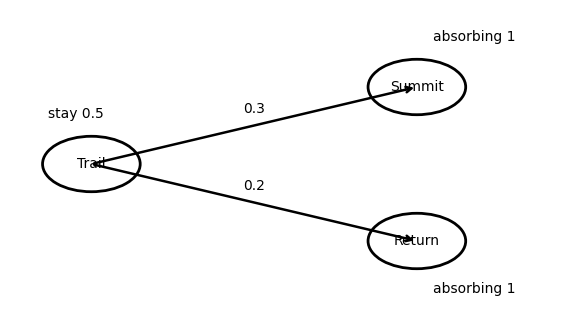

In [42]:
# Directed graph for the hiking chain.
fig, ax = plt.subplots(figsize=(7,4))
ax.axis('off')
pos={'Trail':(0.15,0.5),'Summit':(0.75,0.75),'Return':(0.75,0.25)}
for name,(x,y) in pos.items():
    circ=plt.Circle((x,y),0.09,fill=False,linewidth=2)
    ax.add_patch(circ); ax.text(x,y,name,ha='center',va='center')

def arrow(a,b,label,rad=0.0):
    ax.annotate('',xy=pos[b],xytext=pos[a],arrowprops=dict(arrowstyle='->',connectionstyle=f'arc3,rad={rad}',lw=1.8))
    mx=(pos[a][0]+pos[b][0])/2; my=(pos[a][1]+pos[b][1])/2
    ax.text(mx,my+0.04,label,ha='center')
arrow('Trail','Summit','0.3')
arrow('Trail','Return','0.2')
# self loops as text labels for clarity
ax.text(0.07,0.65,'stay 0.5')
ax.text(0.78,0.90,'absorbing 1')
ax.text(0.78,0.08,'absorbing 1')
ax.set_xlim(0,1); ax.set_ylim(0,1)
plt.show()

> **Closing note**
> Markov chains turn repeated probabilistic transitions into matrix powers. A steady state is a balance vector that is unchanged by the transition matrix. Absorbing chains model eventual outcomes rather than long-run mixing.

## Section 2.5 terminology

| Term | Meaning |
|---|---|
| State | Category occupied by a member of the population |
| Transition probability | Probability of moving from one state to another |
| Stochastic matrix | Nonnegative matrix whose columns sum to $1$ |
| State vector | Column of state proportions or probabilities |
| Markov chain | Repeated process governed by a fixed transition matrix |
| $n$th state | $\mathbf{x}_n=P^n\mathbf{x}_0$ |
| Steady state | Probability vector satisfying $P\mathbf{q}=\mathbf{q}$ |
| Regular matrix | Stochastic matrix for which some positive power has all positive entries |
| Absorbing state | State with probability $1$ of remaining there |
| Absorbing chain | Chain that can eventually reach an absorbing state |

## Section 2.5 worksheet

1. Determine whether each matrix is column-stochastic:

$$
A=\begin{bmatrix}0.7&0.2\\0.3&0.8\end{bmatrix},
\qquad
B=\begin{bmatrix}0.6&0.5\\0.5&0.5\end{bmatrix}.
$$

2. For

$$
P=\begin{bmatrix}0.75&0.25\\0.25&0.75\end{bmatrix},
\qquad
\mathbf{x}_0=\begin{bmatrix}0.8\\0.2\end{bmatrix},
$$

find $\mathbf{x}_1$, $\mathbf{x}_2$, and $\mathbf{x}_5$.

3. Find the steady state of the matrix in Problem 2.

4. For the three-state matrix

$$
P=\begin{bmatrix}0.6&0.2&0.1\\0.3&0.7&0.2\\0.1&0.1&0.7\end{bmatrix},
$$

verify that it is stochastic and find the next state from

$$
\mathbf{x}_0=\begin{bmatrix}0.4\\0.4\\0.2\end{bmatrix}.
$$

5. Consider the absorbing chain

$$
P=\begin{bmatrix}0.4&0&0\\0.35&1&0\\0.25&0&1\end{bmatrix}.
$$

Identify the absorbing states and find the limiting absorption probabilities when the process starts in State 1.

> Use the individual reveal buttons below one problem at a time after students have worked on the questions.

## Section 2.5 Instructor Answer Reveals

Reveal one solution at a time during class. The complete solutions are stored in the hidden instructor answer bank.

In [43]:
reveal_answer_key("2.5-1", "Reveal Problem 1")
reveal_answer_key("2.5-2", "Reveal Problem 2")
reveal_answer_key("2.5-3", "Reveal Problem 3")
reveal_answer_key("2.5-4", "Reveal Problem 4")
reveal_answer_key("2.5-5", "Reveal Problem 5")

ToggleButton(value=False, button_style='info', description='Reveal Problem 5', icon='eye', layout=Layout(width…


> **Classroom checkpoint — Predict a Markov chain**
> Work independently or in small groups before clicking the reveal button below.

A two-state column-stochastic transition matrix is $P=\begin{bmatrix}0.8&0.3\\0.2&0.7\end{bmatrix}$. Starting from $(100,0)^T$, find the state after four transitions and the long-run proportions.


In [44]:
reveal_answer_key("checkpoint-2.5", "Reveal checkpoint answer")

ToggleButton(value=False, button_style='info', description='Reveal checkpoint answer', icon='eye', layout=Layo…

# Section 2.6 - More Applications of Matrix Operations

## Learning objectives

Students should be able to:

- encode and decode a message using an invertible matrix;
- formulate and solve an open Leontief input-output model;
- derive the normal equations for least squares regression;
- compute and interpret a least squares line and residual error.

## Matrix cryptography

Use the mapping

$$
\text{blank}=0,\quad A=1,\quad B=2,\quad\ldots,\quad Z=26.
$$

Encode row vectors on the right using

$$
E=\begin{bmatrix}1&2\\1&3\end{bmatrix}.
$$

Because

$$
\det(E)=1(3)-2(1)=1,
$$

$E$ is invertible and

$$
E^{-1}=\begin{bmatrix}3&-2\\-1&1\end{bmatrix}.
$$

### Original message: GO SPURS GO

The numerical sequence is

$$
7,15,0,19,16,21,18,19,0,7,15,0.
$$

Partition into pairs:

$$
[7\ 15],\ [0\ 19],\ [16\ 21],\ [18\ 19],\ [0\ 7],\ [15\ 0].
$$

Encode each pair:

$$
[7\ 15]E=[22\ 59],
$$

$$
[0\ 19]E=[19\ 57],
$$

$$
[16\ 21]E=[37\ 95],
$$

$$
[18\ 19]E=[37\ 93],
$$

$$
[0\ 7]E=[7\ 21],
$$

$$
[15\ 0]E=[15\ 30].
$$

The cryptogram is

$$
22,59,19,57,37,95,37,93,7,21,15,30.
$$

To decode, multiply each coded row by $E^{-1}$ on the right.

In [55]:
letter_to_num={' ':0, **{chr(64+i):i for i in range(1,27)}}
num_to_letter={v:k for k,v in letter_to_num.items()}
E=sp.Matrix([[1,2],[1,3]])
Einv=E.inv()

def encode_message(message, matrix=E):
    nums=[letter_to_num[ch] for ch in message.upper()]
    if len(nums)%2: nums.append(0)
    coded=[]
    for i in range(0,len(nums),2):
        coded.extend(list(sp.Matrix([[nums[i],nums[i+1]]])*matrix))
    return nums, [int(v) for v in coded]

def decode_message(coded, inverse=Einv):
    nums=[]
    for i in range(0,len(coded),2):
        nums.extend(list(sp.Matrix([[coded[i],coded[i+1]]])*inverse))
    return ''.join(num_to_letter[int(v)] for v in nums)

nums,coded=encode_message('GO SPURS GO')
print('Numeric message:',nums)
print('Coded:',coded)
print('Decoded:',repr(decode_message(coded)))
show_matrix(E,'E')
show_matrix(Einv,'E^{-1}')

Numeric message: [7, 15, 0, 19, 16, 21, 18, 19, 0, 7, 15, 0]
Coded: [22, 59, 19, 57, 37, 95, 37, 93, 7, 21, 15, 30]
Decoded: 'GO SPURS GO '


<IPython.core.display.Math object>

<IPython.core.display.Math object>

⎡3   -2⎤
⎢      ⎥
⎣-1  1 ⎦

## Leontief Input-Output Model

The Leontief input-output model describes how industries depend on one another. Each industry must produce enough output to satisfy both:

1. **internal demand** from the industries in the model; and
2. **external demand** from consumers or sectors outside the model.

Consider three fictional industries:

1. travel services;
2. music and entertainment;
3. sporting goods.

Let

$$
\mathbf{x}=
\begin{bmatrix}
x_1\\x_2\\x_3
\end{bmatrix}
$$

represent their total outputs and let

$$
\mathbf{e}=
\begin{bmatrix}
e_1\\e_2\\e_3
\end{bmatrix}
$$

represent external demand.

Use the internal-consumption matrix

$$
D=
\begin{bmatrix}
0.10&0.05&0.10\\
0.20&0.10&0.05\\
0.05&0.10&0.10
\end{bmatrix}.
$$

### Interpreting the Internal-Consumption Matrix

The matrix

$$
D=
\begin{bmatrix}
0.10&0.05&0.10\\
0.20&0.10&0.05\\
0.05&0.10&0.10
\end{bmatrix}
$$

can be labeled as

$$
D=
\begin{array}{c|ccc}
&
\text{Travel}
&
\text{Music/Entertainment}
&
\text{Sporting Goods}
\\
\hline
\text{Travel}
&
0.10&0.05&0.10
\\
\text{Music/Entertainment}
&
0.20&0.10&0.05
\\
\text{Sporting Goods}
&
0.05&0.10&0.10
\end{array}.
$$

The interpretation is:

> **Columns represent the industry producing the output, while rows represent the industry supplying the input.**

Therefore,

$$
d_{ij}
$$

represents the amount of output from **industry $i$** required to produce one unit of output in **industry $j$**.

---

### Reading the First Column

The first column is

$$
\begin{bmatrix}
0.10\\
0.20\\
0.05
\end{bmatrix}.
$$

This column describes the inputs required to produce one unit of **travel-services output**.

Thus,

$$
d_{11}=0.10
$$

means that producing one unit of travel-services output requires

$$
0.10
$$

units of output from the travel-services industry itself.

Similarly,

$$
d_{21}=0.20
$$

means that producing one unit of travel-services output requires

$$
0.20
$$

units of music-and-entertainment output.

Finally,

$$
d_{31}=0.05
$$

means that producing one unit of travel-services output requires

$$
0.05
$$

units of sporting-goods output.

So we can summarize the first column as

$$
\boxed{
\text{1 unit of Travel output requires }
\begin{cases}
0.10\text{ units of Travel},\\
0.20\text{ units of Music/Entertainment},\\
0.05\text{ units of Sporting Goods}.
\end{cases}
}
$$

---

### Reading the Second Column

The second column is

$$
\begin{bmatrix}
0.05\\
0.10\\
0.10
\end{bmatrix}.
$$

It describes the inputs required to produce one unit of **music-and-entertainment output**.

Therefore,

$$
\boxed{
\text{1 unit of Music/Entertainment output requires }
\begin{cases}
0.05\text{ units of Travel},\\
0.10\text{ units of Music/Entertainment},\\
0.10\text{ units of Sporting Goods}.
\end{cases}
}
$$

---

### Reading the Third Column

The third column is

$$
\begin{bmatrix}
0.10\\
0.05\\
0.10
\end{bmatrix}.
$$

It describes the inputs required to produce one unit of **sporting-goods output**.

Thus,

$$
\boxed{
\text{1 unit of Sporting Goods output requires }
\begin{cases}
0.10\text{ units of Travel},\\
0.05\text{ units of Music/Entertainment},\\
0.10\text{ units of Sporting Goods}.
\end{cases}
}
$$

---

### Example: How to Interpret One Entry

Consider

$$
d_{12}=0.05.
$$

The first index tells us the **supplying industry**:

$$
i=1
\quad\Longrightarrow\quad
\text{Travel}.
$$

The second index tells us the **producing industry**:

$$
j=2
\quad\Longrightarrow\quad
\text{Music/Entertainment}.
$$

Therefore,

$$
\boxed{
d_{12}=0.05
}
$$

means:

> Producing one unit of music-and-entertainment output requires $0.05$ units of travel-services output.

Similarly,

$$
d_{23}=0.05
$$

means:

> Producing one unit of sporting-goods output requires $0.05$ units of music-and-entertainment output.

---

> **Key Reading Rule**
>
> For the input-output matrix $D$:
>
> $$
> \boxed{
> \text{Row}=\text{supplying industry},
> \qquad
> \text{Column}=\text{producing industry}.
> }
> $$
>
> Therefore,
>
> $$
> \boxed{
> d_{ij}
> =
> \text{amount supplied by industry }i
> \text{ per unit produced by industry }j.
> }
> $$

### Column convention

The entry $d_{ij}$ represents the amount of output from **industry $i$** required to produce one unit of output from **industry $j$**. Thus columns correspond to the producing industry and rows correspond to the supplying industry.

For example,

$$
d_{12}=0.05
$$

means that producing one unit of music/entertainment output requires $0.05$ units of travel-service output.

The vector

$$
D\mathbf{x}
$$

is the total **internal demand** generated by production. The balance equation is

$$
\mathbf{x}=D\mathbf{x}+\mathbf{e}.
$$

Remember that $$\mathbf{e}$$ is the **external demand**. Move internal demand to the left:

$$
(I-D)\mathbf{x}=\mathbf{e}.
$$

If $I-D$ is invertible, then

$$
\mathbf{x}=(I-D)^{-1}\mathbf{e}.
$$

The matrix $(I-D)^{-1}$ is called the **Leontief inverse**.

Suppose

$$
\mathbf{e}=
\begin{bmatrix}
95\\62\\56
\end{bmatrix}.
$$

Then

$$
I-D=
\begin{bmatrix}
0.90&-0.05&-0.10\\
-0.20&0.90&-0.05\\
-0.05&-0.10&0.90
\end{bmatrix}.
$$

Multiplying the system by $20$ clears the decimals:

$$
\begin{bmatrix}
18&-1&-2\\
-4&18&-1\\
-1&-2&18
\end{bmatrix}
\mathbf{x}
=
\begin{bmatrix}
1900\\1240\\1120
\end{bmatrix}.
$$

Solving gives

$$
\boxed{
\mathbf{x}=
\begin{bmatrix}
120\\100\\80
\end{bmatrix}
}.
$$

The internal demand is

$$
D\mathbf{x}=
\begin{bmatrix}
25\\38\\24
\end{bmatrix}.
$$

Therefore,

$$
D\mathbf{x}+\mathbf{e}
=
\begin{bmatrix}
25\\38\\24
\end{bmatrix}
+
\begin{bmatrix}
95\\62\\56
\end{bmatrix}
=
\begin{bmatrix}
120\\100\\80
\end{bmatrix}
=\mathbf{x},
$$

which verifies the model.

### Classroom Check: Interpret an Input-Output Entry

In the Leontief matrix, what does

$$
d_{12}=0.05
$$

mean? Pay attention to the row and column convention.

In [46]:
reveal_answer_key("concept-leontief-column", "Reveal interpretation")

The entry

$$
d_{12}=0.05
$$

lies in row 1 and column 2.

- Row 1 corresponds to the supplying industry: **travel services**.
- Column 2 corresponds to the producing industry: **music and entertainment**.

Therefore $d_{12}=0.05$ means that producing one unit of music/entertainment output requires $0.05$ units of travel-service output.

In [47]:
D_io=sp.Matrix([[sp.Rational(1,10),sp.Rational(1,20),sp.Rational(1,10)],
                [sp.Rational(1,5),sp.Rational(1,10),sp.Rational(1,20)],
                [sp.Rational(1,20),sp.Rational(1,10),sp.Rational(1,10)]])
e_io=sp.Matrix([95,62,56])
M_io=sp.eye(3)-D_io
x_io=M_io.inv()*e_io
show_matrix(D_io,'D')
show_matrix(M_io,'I-D')
show_matrix(x_io,r'\mathbf{x}')
show_matrix(D_io*x_io+e_io,r'D\mathbf{x}+\mathbf{e}')

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

⎡120⎤
⎢   ⎥
⎢100⎥
⎢   ⎥
⎣80 ⎦

## Least-Squares Regression

Suppose we are given the five data points

$$
(1,8),\qquad
(2,9),\qquad
(3,17),\qquad
(4,17),\qquad
(5,24).
$$

We want to find a straight line that fits these data as closely as possible.

We assume a linear model of the form

$$
\widehat y=a_0+a_1x,
$$

where

- $a_0$ is the **intercept**;
- $a_1$ is the **slope**;
- $\widehat y$ represents the value predicted by the fitted line.

Our goal is to determine the coefficients

$$
a_0
\qquad\text{and}\qquad
a_1.
$$

---

### Step 1: Write the five equations

If the fitted line passed exactly through every data point, then we would have

$$
8=a_0+a_1(1),
$$

$$
9=a_0+a_1(2),
$$

$$
17=a_0+a_1(3),
$$

$$
17=a_0+a_1(4),
$$

and

$$
24=a_0+a_1(5).
$$

Equivalently,

$$
\begin{cases}
a_0+a_1=8,\\
a_0+2a_1=9,\\
a_0+3a_1=17,\\
a_0+4a_1=17,\\
a_0+5a_1=24.
\end{cases}
$$

There are

$$
5
$$

equations but only

$$
2
$$

unknown coefficients.

This is an **overdetermined system**.

The five data points do not all lie on one straight line, so there is no single pair $(a_0,a_1)$ that satisfies all five equations exactly.

Therefore, instead of looking for an exact solution, we look for the line that gives the **best approximation**.

---

### Step 2: Write the model in matrix form

We can write all five equations simultaneously as

$$
X\mathbf{a}\approx\mathbf{y},
$$

where

$$
X=
\begin{bmatrix}
1&1\\
1&2\\
1&3\\
1&4\\
1&5
\end{bmatrix},
\qquad
\mathbf{a}=
\begin{bmatrix}
a_0\\
a_1
\end{bmatrix},
\qquad
\mathbf{y}=
\begin{bmatrix}
8\\
9\\
17\\
17\\
24
\end{bmatrix}.
$$

The matrix $X$ is called the **design matrix**.

Its first column is

$$
\begin{bmatrix}
1\\
1\\
1\\
1\\
1
\end{bmatrix},
$$

which corresponds to the intercept term $a_0$.

Its second column is

$$
\begin{bmatrix}
1\\
2\\
3\\
4\\
5
\end{bmatrix},
$$

which contains the observed $x$-values and corresponds to the slope coefficient $a_1$.

Now multiply:

$$
X\mathbf{a}
=
\begin{bmatrix}
1&1\\
1&2\\
1&3\\
1&4\\
1&5
\end{bmatrix}
\begin{bmatrix}
a_0\\
a_1
\end{bmatrix}.
$$

Using the row-by-column rule,

$$
X\mathbf{a}
=
\begin{bmatrix}
a_0+a_1\\
a_0+2a_1\\
a_0+3a_1\\
a_0+4a_1\\
a_0+5a_1
\end{bmatrix}.
$$

These are exactly the five predicted values:

$$
X\mathbf{a}
=
\begin{bmatrix}
\widehat y_1\\
\widehat y_2\\
\widehat y_3\\
\widehat y_4\\
\widehat y_5
\end{bmatrix}.
$$

---

### Step 3: Define the residual vector

Because the fitted line does not usually pass through every data point, the predicted vector

$$
X\mathbf{a}
$$

will not equal the observed vector

$$
\mathbf{y}.
$$

The difference is called the **residual vector**:

$$
\boxed{
\mathbf{r}
=
\mathbf{y}-X\mathbf{a}
}.
$$

Each residual is

$$
r_i=y_i-\widehat y_i.
$$

Thus,

- a positive residual means the observed point lies above the fitted line;
- a negative residual means the observed point lies below the fitted line;
- a zero residual means the fitted line passes exactly through that observation.

Least squares chooses $\mathbf{a}$ so that the total squared residual is as small as possible:

$$
\boxed{
\|\mathbf{y}-X\mathbf{a}\|^2
}.
$$

Since

$$
\mathbf{r}
=
\mathbf{y}-X\mathbf{a},
$$

this is equivalent to minimizing

$$
\|\mathbf{r}\|^2.
$$

In coordinates,

$$
\|\mathbf{r}\|^2
=
r_1^2+r_2^2+r_3^2+r_4^2+r_5^2.
$$

This quantity is also called the **sum of squared errors**, or SSE.

---

## Why Is the Residual Orthogonal to the Columns of $X$?

The vector

$$
X\mathbf{a}
$$

is a linear combination of the columns of $X$.

Indeed, if

$$
X=
\begin{bmatrix}
\mathbf{x}_1&\mathbf{x}_2
\end{bmatrix},
$$

then

$$
X\mathbf{a}
=
a_0\mathbf{x}_1+a_1\mathbf{x}_2.
$$

Therefore,

$$
X\mathbf{a}
$$

lies in the space generated by the columns of $X$.

The least-squares solution chooses the vector $X\mathbf{a}$ in this space that is **closest to $\mathbf{y}$**.

Geometrically, the shortest distance from a point to a line, plane, or higher-dimensional subspace occurs in the perpendicular direction.

Therefore, at the least-squares solution,

$$
\boxed{
\mathbf{r}
=
\mathbf{y}-X\mathbf{a}
}
$$

must be perpendicular to every column of $X$.

If the columns of $X$ are $\mathbf{x}_1$ and $\mathbf{x}_2$, then

$$
\mathbf{x}_1^T\mathbf{r}=0
$$

and

$$
\mathbf{x}_2^T\mathbf{r}=0.
$$

Writing both equations simultaneously gives

$$
\boxed{
X^T\mathbf{r}=\mathbf{0}.
}
$$

---

### Step 4: Derive the normal equations

Recall that

$$
\mathbf{r}
=
\mathbf{y}-X\mathbf{a}.
$$

Substitute this into

$$
X^T\mathbf{r}=\mathbf{0}.
$$

We obtain

$$
X^T(\mathbf{y}-X\mathbf{a})
=
\mathbf{0}.
$$

Distribute $X^T$:

$$
X^T\mathbf{y}
-
X^TX\mathbf{a}
=
\mathbf{0}.
$$

Therefore,

$$
\boxed{
X^TX\mathbf{a}
=
X^T\mathbf{y}
}.
$$

These equations are called the **normal equations**.

> **Important idea**
>
> The normal equations are not simply a computational formula.
>
> They come from the geometric fact that the least-squares residual is perpendicular to the columns of $X$.

---

## Step 5: Compute $X^TX$

First,

$$
X^T=
\begin{bmatrix}
1&1&1&1&1\\
1&2&3&4&5
\end{bmatrix}.
$$

Therefore,

$$
X^TX
=
\begin{bmatrix}
1&1&1&1&1\\
1&2&3&4&5
\end{bmatrix}
\begin{bmatrix}
1&1\\
1&2\\
1&3\\
1&4\\
1&5
\end{bmatrix}.
$$

Compute each entry.

The $(1,1)$ entry is

$$
1^2+1^2+1^2+1^2+1^2
=
5.
$$

The $(1,2)$ entry is

$$
1(1)+1(2)+1(3)+1(4)+1(5)
=
15.
$$

The $(2,1)$ entry is also

$$
15.
$$

The $(2,2)$ entry is

$$
1^2+2^2+3^2+4^2+5^2
=
1+4+9+16+25
=
55.
$$

Thus,

$$
\boxed{
X^TX=
\begin{bmatrix}
5&15\\
15&55
\end{bmatrix}
}.
$$

For simple linear regression, notice the useful pattern

$$
X^TX
=
\begin{bmatrix}
n&\sum x_i\\
\sum x_i&\sum x_i^2
\end{bmatrix}.
$$

Here,

$$
n=5,
\qquad
\sum x_i=15,
\qquad
\sum x_i^2=55.
$$

---

## Step 6: Compute $X^T\mathbf{y}$

We have

$$
X^T\mathbf{y}
=
\begin{bmatrix}
1&1&1&1&1\\
1&2&3&4&5
\end{bmatrix}
\begin{bmatrix}
8\\
9\\
17\\
17\\
24
\end{bmatrix}.
$$

The first entry is

$$
8+9+17+17+24
=
75.
$$

The second entry is

$$
1(8)+2(9)+3(17)+4(17)+5(24).
$$

Compute:

$$
8+18+51+68+120
=
265.
$$

Therefore,

$$
\boxed{
X^T\mathbf{y}
=
\begin{bmatrix}
75\\
265
\end{bmatrix}
}.
$$

For simple linear regression, this has the form

$$
X^T\mathbf{y}
=
\begin{bmatrix}
\sum y_i\\
\sum x_iy_i
\end{bmatrix}.
$$

---

## Step 7: Solve the normal equations

The normal equations are

$$
X^TX\mathbf{a}
=
X^T\mathbf{y}.
$$

Substituting the matrices gives

$$
\begin{bmatrix}
5&15\\
15&55
\end{bmatrix}
\begin{bmatrix}
a_0\\
a_1
\end{bmatrix}
=
\begin{bmatrix}
75\\
265
\end{bmatrix}.
$$

Therefore,

$$
\begin{cases}
5a_0+15a_1=75,\\
15a_0+55a_1=265.
\end{cases}
$$

Multiply the first equation by $3$:

$$
15a_0+45a_1=225.
$$

Subtract this equation from the second equation:

$$
(15a_0+55a_1)
-
(15a_0+45a_1)
=
265-225.
$$

Thus,

$$
10a_1=40.
$$

Therefore,

$$
\boxed{
a_1=4
}.
$$

Substitute $a_1=4$ into the first equation:

$$
5a_0+15(4)=75.
$$

So

$$
5a_0+60=75,
$$

and hence

$$
5a_0=15.
$$

Therefore,

$$
\boxed{
a_0=3
}.
$$

The least-squares coefficient vector is

$$
\boxed{
\mathbf{a}
=
\begin{bmatrix}
3\\
4
\end{bmatrix}
}.
$$

Thus the least-squares regression line is

$$
\boxed{
\widehat y=3+4x
}.
$$

---

## Step 8: Compute the predicted values

Using

$$
\widehat y=3+4x,
$$

we obtain

$$
\begin{array}{c|c|c}
x&y&\widehat y=3+4x\\
\hline
1&8&7\\
2&9&11\\
3&17&15\\
4&17&19\\
5&24&23
\end{array}.
$$

Therefore,

$$
X\mathbf{a}
=
\begin{bmatrix}
7\\
11\\
15\\
19\\
23
\end{bmatrix}.
$$

---

## Step 9: Compute the residual vector

Recall

$$
\mathbf{r}
=
\mathbf{y}-X\mathbf{a}.
$$

Therefore,

$$
\mathbf{r}
=
\begin{bmatrix}
8\\
9\\
17\\
17\\
24
\end{bmatrix}
-
\begin{bmatrix}
7\\
11\\
15\\
19\\
23
\end{bmatrix}.
$$

Thus,

$$
\boxed{
\mathbf{r}
=
\begin{bmatrix}
1\\
-2\\
2\\
-2\\
1
\end{bmatrix}
}.
$$

The individual residuals are therefore

$$
1,\qquad -2,\qquad 2,\qquad -2,\qquad 1.
$$

For example,

$$
r_1=8-7=1,
$$

so the first observed point lies $1$ unit above the fitted line.

Similarly,

$$
r_2=9-11=-2,
$$

so the second observed point lies $2$ units below the fitted line.

---

## Step 10: Verify the orthogonality condition

The two columns of $X$ are

$$
\mathbf{x}_1=
\begin{bmatrix}
1\\
1\\
1\\
1\\
1
\end{bmatrix},
\qquad
\mathbf{x}_2=
\begin{bmatrix}
1\\
2\\
3\\
4\\
5
\end{bmatrix}.
$$

The residual should be perpendicular to both.

For the first column,

$$
\mathbf{x}_1^T\mathbf{r}
=
1-2+2-2+1
=
0.
$$

For the second column,

$$
\mathbf{x}_2^T\mathbf{r}
=
1(1)+2(-2)+3(2)+4(-2)+5(1).
$$

Therefore,

$$
1-4+6-8+5
=
0.
$$

Thus,

$$
\boxed{
X^T\mathbf{r}=\mathbf{0}
}.
$$

This verifies that the residual is orthogonal to both columns of $X$.

---

## Step 11: Compute the Sum of Squared Errors

The sum of squared errors is

$$
\mathrm{SSE}
=
\|\mathbf{r}\|^2.
$$

Therefore,

$$
\mathrm{SSE}
=
1^2+(-2)^2+2^2+(-2)^2+1^2.
$$

Hence,

$$
\mathrm{SSE}
=
1+4+4+4+1
=
\boxed{14}.
$$

The least-squares line is the line that minimizes this quantity among all lines of the form

$$
y=a_0+a_1x.
$$

---

## Matrix Formula for the Least-Squares Solution

If $X^TX$ is invertible, then from

$$
X^TX\mathbf{a}
=
X^T\mathbf{y},
$$

we can multiply by $(X^TX)^{-1}$ to obtain

$$
\boxed{
\mathbf{a}
=
(X^TX)^{-1}X^T\mathbf{y}
}.
$$

For small problems, this formula is useful for understanding the mathematics.

For larger numerical problems, however, we generally do **not** explicitly compute

$$
(X^TX)^{-1}.
$$

Numerical methods based on QR factorization are typically more stable and efficient.

---

> **Summary: Least Squares**
>
> Starting with an overdetermined system
>
> $$
> X\mathbf{a}\approx\mathbf{y},
> $$
>
> we define the residual
>
> $$
> \mathbf{r}
> =
> \mathbf{y}-X\mathbf{a}.
> $$
>
> Least squares minimizes
>
> $$
> \|\mathbf{r}\|^2.
> $$
>
> At the optimal solution,
>
> $$
> \mathbf{r}
> \perp
> \text{every column of }X,
> $$
>
> so
>
> $$
> X^T\mathbf{r}
> =
> \mathbf{0}.
> $$
>
> Substituting
>
> $$
> \mathbf{r}
> =
> \mathbf{y}-X\mathbf{a}
> $$
>
> gives the normal equations
>
> $$
> \boxed{
> X^TX\mathbf{a}
> =
> X^T\mathbf{y}
> }.
> $$
>
> For this example,
>
> $$
> \boxed{
> \widehat y=3+4x
> }
> $$
>
> with residual
>
> $$
> \boxed{
> \mathbf{r}
> =
> \begin{bmatrix}
> 1\\
> -2\\
> 2\\
> -2\\
> 1
> \end{bmatrix}
> }
> $$
>
> and
>
> $$
> \boxed{
> \mathrm{SSE}=14
> }.
> $$

### Classroom Question: Why Least Squares?

Why do we generally not solve

$$
X\mathbf{a}=\mathbf{y}
$$

exactly for the five-point line-fitting example? What does least squares do instead?

In [48]:
reveal_answer_key("concept-least-squares", "Reveal explanation")

The equation

$$
X\mathbf{a}=\mathbf{y}
$$

represents five data equations but only two unknown coefficients, $a_0$ and $a_1$. Unless all five points lie exactly on one line, those five equations cannot all be satisfied simultaneously.

Least squares therefore does not force an exact solution. Instead, it chooses $\mathbf{a}$ to minimize

$$
\|\mathbf{y}-X\mathbf{a}\|^2,
$$

which is the sum of the squared residuals.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

SSE = 14


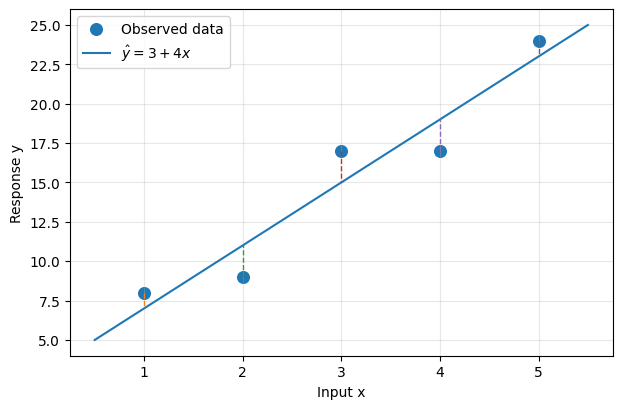

In [49]:
xs=np.array([1,2,3,4,5],dtype=float)
ys=np.array([8,9,17,17,24],dtype=float)
X=sp.Matrix([[1,int(x)] for x in xs])
yvec=sp.Matrix([int(y) for y in ys])
beta=(X.T*X).inv()*X.T*yvec
res=yvec-X*beta
sse=(res.T*res)[0]
show_matrix(X.T*X,'X^TX')
show_matrix(X.T*yvec,r'X^T\mathbf{y}')
show_matrix(beta,r'\mathbf{a}')
show_matrix(res,r'\mathbf{r}')
print('SSE =',sse)
plt.figure(figsize=(7,4.5))
plt.scatter(xs,ys,s=70,label='Observed data')
xx=np.linspace(.5,5.5,200)
plt.plot(xx,3+4*xx,label=r'$\hat y=3+4x$')
for x,y in zip(xs,ys):
    plt.plot([x,x],[y,3+4*x],linestyle='--',linewidth=1)
plt.xlabel('Input x')
plt.ylabel('Response y')
plt.grid(alpha=.3)
plt.legend()
plt.show()

intercept = 3.0000, slope = 4.0000, SSE = 14.0000


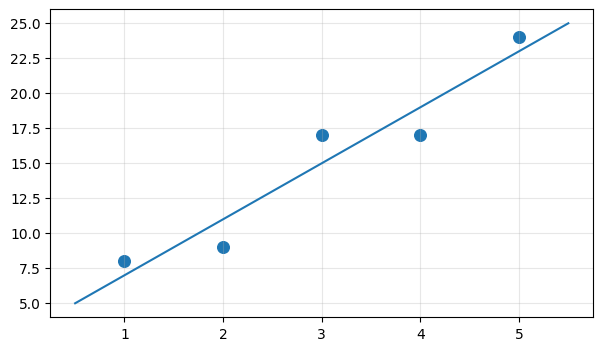

In [50]:
# Optional exploration: change the y-values and rerun.
def fit_and_plot(x_values, y_values):
    x_values=np.asarray(x_values,dtype=float)
    y_values=np.asarray(y_values,dtype=float)
    design=np.column_stack([np.ones(len(x_values)),x_values])
    coef=np.linalg.lstsq(design,y_values,rcond=None)[0]
    predictions=design@coef
    sse=float(np.sum((y_values-predictions)**2))
    print(f'intercept = {coef[0]:.4f}, slope = {coef[1]:.4f}, SSE = {sse:.4f}')
    grid=np.linspace(x_values.min()-.5,x_values.max()+.5,200)
    plt.figure(figsize=(7,4))
    plt.scatter(x_values,y_values,s=70)
    plt.plot(grid,coef[0]+coef[1]*grid)
    plt.grid(alpha=.3)
    plt.show()

fit_and_plot([1,2,3,4,5],[8,9,17,17,24])

> **Closing note**
>
> Cryptography uses invertible matrix transformations, Leontief models use $(I-D)^{-1}$ to account for internal demand, and least squares uses matrix equations to construct a best-fit approximation when an exact fit is unavailable. These applications show how the same matrix operations support very different fields.

## Section 2.6 terminology

| Term | Meaning |
|---|---|
| Cryptogram | Encoded numerical message |
| Encoding matrix | Invertible matrix used to transform message blocks |
| Decoding matrix | Inverse of the encoding matrix |
| Input-output matrix $D$ | Internal consumption coefficients in a Leontief model |
| External demand $\mathbf{e}$ | Demand from outside the modeled industries |
| Total output $\mathbf{x}$ | Production required to meet internal and external demand |
| Least squares line | Line minimizing the sum of squared residuals |
| Design matrix $X$ | Matrix containing regression predictor structure |
| Normal equations | $X^TX\mathbf{a}=X^T\mathbf{y}$ |
| Residual | Observed value minus predicted value |
| SSE | Sum of squared errors |

## Section 2.6 worksheet

1. Use the mapping blank $=0$, $A=1$, ..., $Z=26$ and

$$
E=\begin{bmatrix}1&1\\1&2\end{bmatrix}
$$

to encode the message **RNB MUSIC**. Pad with a blank if necessary.

2. Find $E^{-1}$ and decode the first two coded blocks from Problem 1.

3. A fictional two-industry economy has

$$
D=\begin{bmatrix}0.20&0.10\\0.25&0.20\end{bmatrix},
\qquad
\mathbf{e}=\begin{bmatrix}70\\55\end{bmatrix}.
$$

Solve $(I-D)\mathbf{x}=\mathbf{e}$.

4. Find the least squares line for

$$
(1,4),\ (2,7),\ (3,8),\ (4,13).
$$

Show $X$, $X^TX$, $X^T\mathbf{y}$, the normal equations, and the SSE.

> Use the individual reveal buttons below one problem at a time after students have worked on the questions.

## Section 2.6 Instructor Answer Reveals

Reveal one solution at a time during class. The complete solutions are stored in the hidden instructor answer bank.

In [51]:
reveal_answer_key("2.6-1", "Reveal Problem 1")
reveal_answer_key("2.6-2", "Reveal Problem 2")
reveal_answer_key("2.6-3", "Reveal Problem 3")
reveal_answer_key("2.6-4", "Reveal Problem 4")

ToggleButton(value=False, button_style='info', description='Reveal Problem 4', icon='eye', layout=Layout(width…

# Chapter 2 Summary

The chapter develops a connected sequence:

$$
\text{matrix operations}
\longrightarrow
\text{matrix algebra}
\longrightarrow
\text{inverses and elementary matrices}
\longrightarrow
\text{LU-factorization}
\longrightarrow
\text{dynamic and applied models}.
$$

Core computational habits:

1. check matrix dimensions before every operation;
2. show row-column products explicitly when multiplying;
3. verify inverses by multiplication;
4. record every elementary row operation;
5. keep the order of matrix products intact;
6. interpret matrix results in the original application context;
7. use Python to verify, not replace, mathematical reasoning.

> **Instructor closing note**
> The notebook intentionally contains more examples than one class meeting can cover. Select the core example in each subsection, then use optional code and applications when students need another viewpoint or when time remains.


> **Classroom checkpoint — Fit a least-squares line**
> Work independently or in small groups before clicking the reveal button below.

Find the least-squares line $y=a_0+a_1x$ for $(0,1),(1,2),(2,2),(3,4)$. Identify the normal equations and the fitted coefficients.


In [52]:
reveal_answer_key("checkpoint-2.6", "Reveal checkpoint answer")

ToggleButton(value=False, button_style='info', description='Reveal checkpoint answer', icon='eye', layout=Layo…